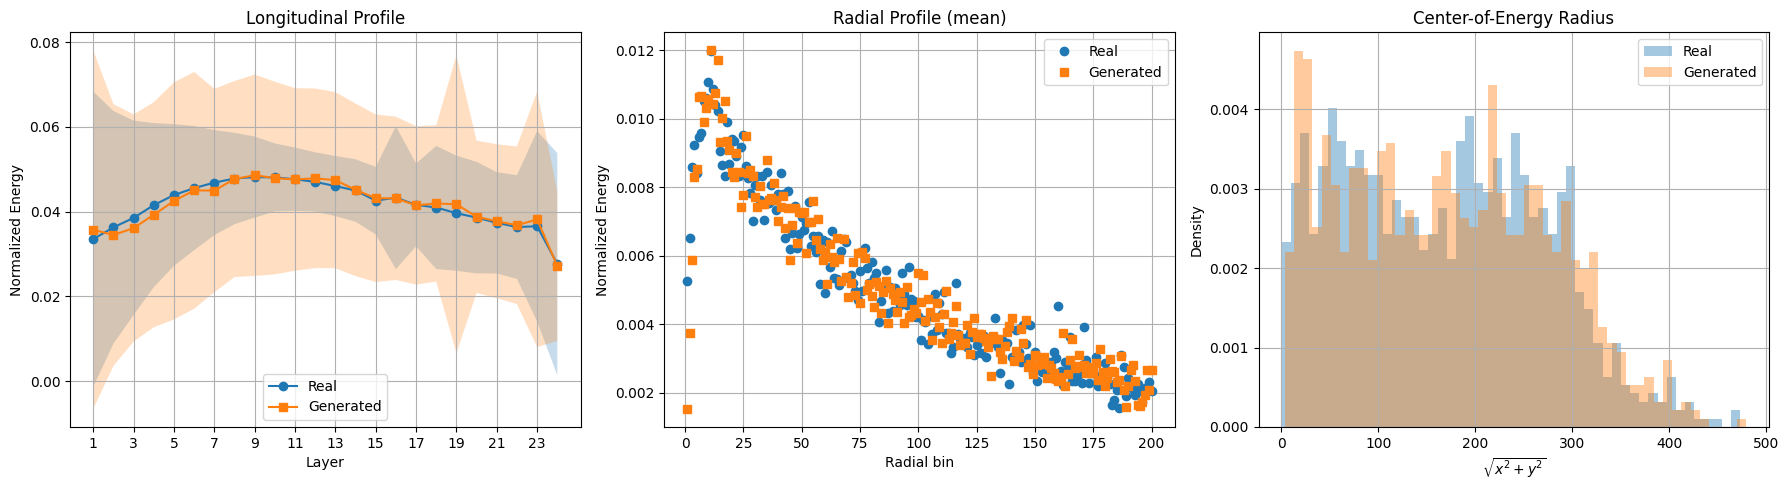

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

gen_file  = "/n/home04/hhanif/AllShowers/results/20260305_141348_CNF-Transformer/samples00.h5"
real_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_v5/merged_all_showers_test.h5"

def load_obs(path):
    with h5py.File(path, "r") as f:
        layer  = f["observables/energy_per_layer"][:]          # (N,24)
        radial = f["observables/energy_per_radial_bin"][:]     # (N,200)
        center = f["observables/center_of_energy"][:]          # (N,3)
    return layer, radial, center

gen_layer, gen_radial, gen_center   = load_obs(gen_file)
real_layer, real_radial, real_center = load_obs(real_file)

# -------------------- normalize per shower --------------------
gen_layer  = gen_layer  / gen_layer.sum(axis=1, keepdims=True)
real_layer = real_layer / real_layer.sum(axis=1, keepdims=True)

gen_radial  = gen_radial  / gen_radial.sum(axis=1, keepdims=True)
real_radial = real_radial / real_radial.sum(axis=1, keepdims=True)

# -------------------- stats --------------------
layers = np.arange(1, 25)
rbins  = np.arange(1, gen_radial.shape[1] + 1)

gL_m, gL_s = gen_layer.mean(axis=0),  gen_layer.std(axis=0)
rL_m, rL_s = real_layer.mean(axis=0), real_layer.std(axis=0)

gR_m, gR_s = gen_radial.mean(axis=0),  gen_radial.std(axis=0)
rR_m, rR_s = real_radial.mean(axis=0), real_radial.std(axis=0)

# Center-of-energy: compare 1D distributions of radius in xy-plane
gC_r = np.sqrt(gen_center[:, 0]**2 + gen_center[:, 1]**2)
rC_r = np.sqrt(real_center[:, 0]**2 + real_center[:, 1]**2)

# -------------------- 3-panel figure --------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Longitudinal profile
ax = axes[0]
ax.plot(layers, rL_m, marker='o', label="Real")
ax.fill_between(layers, rL_m - rL_s, rL_m + rL_s, alpha=0.25)
ax.plot(layers, gL_m, marker='s', label="Generated")
ax.fill_between(layers, gL_m - gL_s, gL_m + gL_s, alpha=0.25)
ax.set_xlabel("Layer")
ax.set_ylabel("Normalized Energy")
ax.set_title("Longitudinal Profile")
ax.set_xticks(np.arange(1, 25, 2))
ax.grid(True)
ax.legend()

# (2) Radial profile
ax = axes[1]
ax.plot(rbins, rR_m, marker='o', linestyle='None', label="Real")
ax.plot(rbins, gR_m, marker='s', linestyle='None', label="Generated")
ax.set_xlabel("Radial bin")
ax.set_ylabel("Normalized Energy")
ax.set_title("Radial Profile (mean)")
ax.grid(True)
ax.legend()

# (3) Center-of-energy radius distribution
ax = axes[2]
ax.hist(rC_r, bins=50, density=True, alpha=0.4, label="Real")
ax.hist(gC_r, bins=50, density=True, alpha=0.4, label="Generated")
ax.set_xlabel(r"$\sqrt{x^2+y^2}$")
ax.set_ylabel("Density")
ax.set_title("Center-of-Energy Radius")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

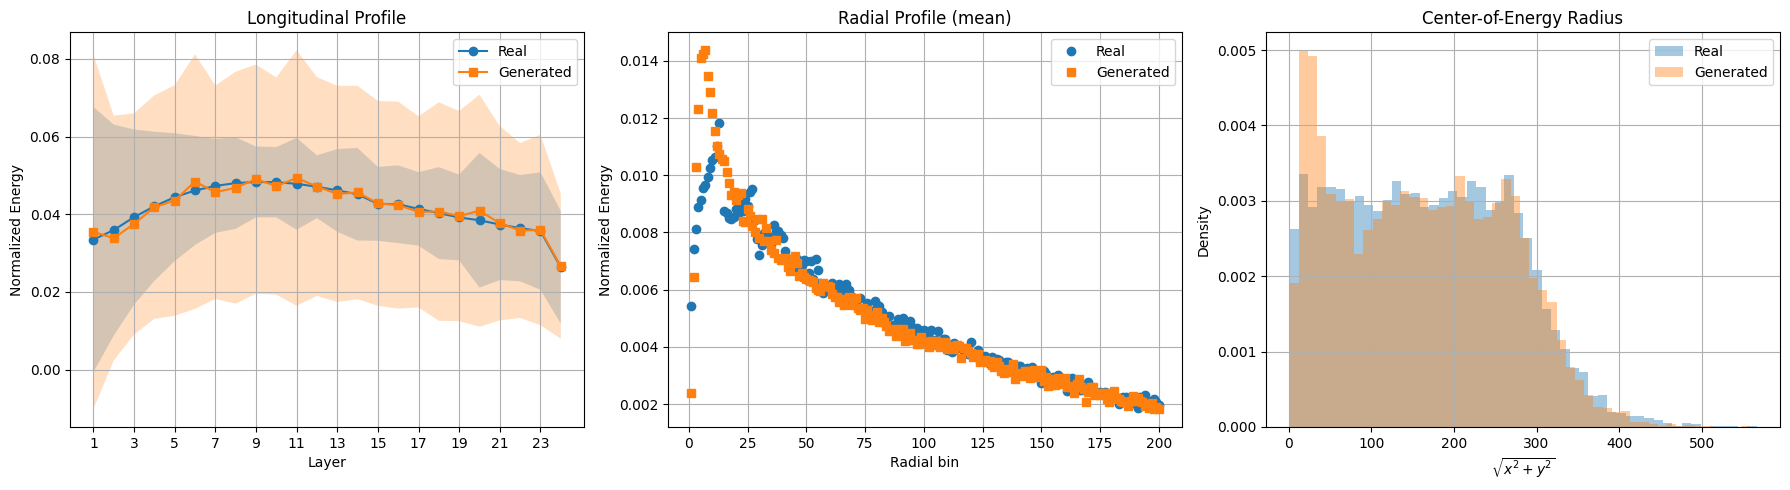

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

gen_file  = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"
real_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"

def load_obs(path):
    with h5py.File(path, "r") as f:
        layer  = f["observables/energy_per_layer"][:]          # (N,24)
        radial = f["observables/energy_per_radial_bin"][:]     # (N,200)
        center = f["observables/center_of_energy"][:]          # (N,3)
    return layer, radial, center

gen_layer, gen_radial, gen_center   = load_obs(gen_file)
real_layer, real_radial, real_center = load_obs(real_file)

# -------------------- normalize per shower --------------------
gen_layer  = gen_layer  / gen_layer.sum(axis=1, keepdims=True)
real_layer = real_layer / real_layer.sum(axis=1, keepdims=True)

gen_radial  = gen_radial  / gen_radial.sum(axis=1, keepdims=True)
real_radial = real_radial / real_radial.sum(axis=1, keepdims=True)

# -------------------- stats --------------------
layers = np.arange(1, 25)
rbins  = np.arange(1, gen_radial.shape[1] + 1)

gL_m, gL_s = gen_layer.mean(axis=0),  gen_layer.std(axis=0)
rL_m, rL_s = real_layer.mean(axis=0), real_layer.std(axis=0)

gR_m, gR_s = gen_radial.mean(axis=0),  gen_radial.std(axis=0)
rR_m, rR_s = real_radial.mean(axis=0), real_radial.std(axis=0)

# Center-of-energy: compare 1D distributions of radius in xy-plane
gC_r = np.sqrt(gen_center[:, 0]**2 + gen_center[:, 1]**2)
rC_r = np.sqrt(real_center[:, 0]**2 + real_center[:, 1]**2)

# -------------------- 3-panel figure --------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Longitudinal profile
ax = axes[0]
ax.plot(layers, rL_m, marker='o', label="Real")
ax.fill_between(layers, rL_m - rL_s, rL_m + rL_s, alpha=0.25)
ax.plot(layers, gL_m, marker='s', label="Generated")
ax.fill_between(layers, gL_m - gL_s, gL_m + gL_s, alpha=0.25)
ax.set_xlabel("Layer")
ax.set_ylabel("Normalized Energy")
ax.set_title("Longitudinal Profile")
ax.set_xticks(np.arange(1, 25, 2))
ax.grid(True)
ax.legend()

# (2) Radial profile
ax = axes[1]
ax.plot(rbins, rR_m, marker='o', linestyle='None', label="Real")
ax.plot(rbins, gR_m, marker='s', linestyle='None', label="Generated")
ax.set_xlabel("Radial bin")
ax.set_ylabel("Normalized Energy")
ax.set_title("Radial Profile (mean)")
ax.grid(True)
ax.legend()

# (3) Center-of-energy radius distribution
ax = axes[2]
ax.hist(rC_r, bins=50, density=True, alpha=0.4, label="Real")
ax.hist(gC_r, bins=50, density=True, alpha=0.4, label="Generated")
ax.set_xlabel(r"$\sqrt{x^2+y^2}$")
ax.set_ylabel("Density")
ax.set_title("Center-of-Energy Radius")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

Loading energy observables...
Loading time observables (looping over showers, may take a moment)...
Done.
Saved to shower_observables.png


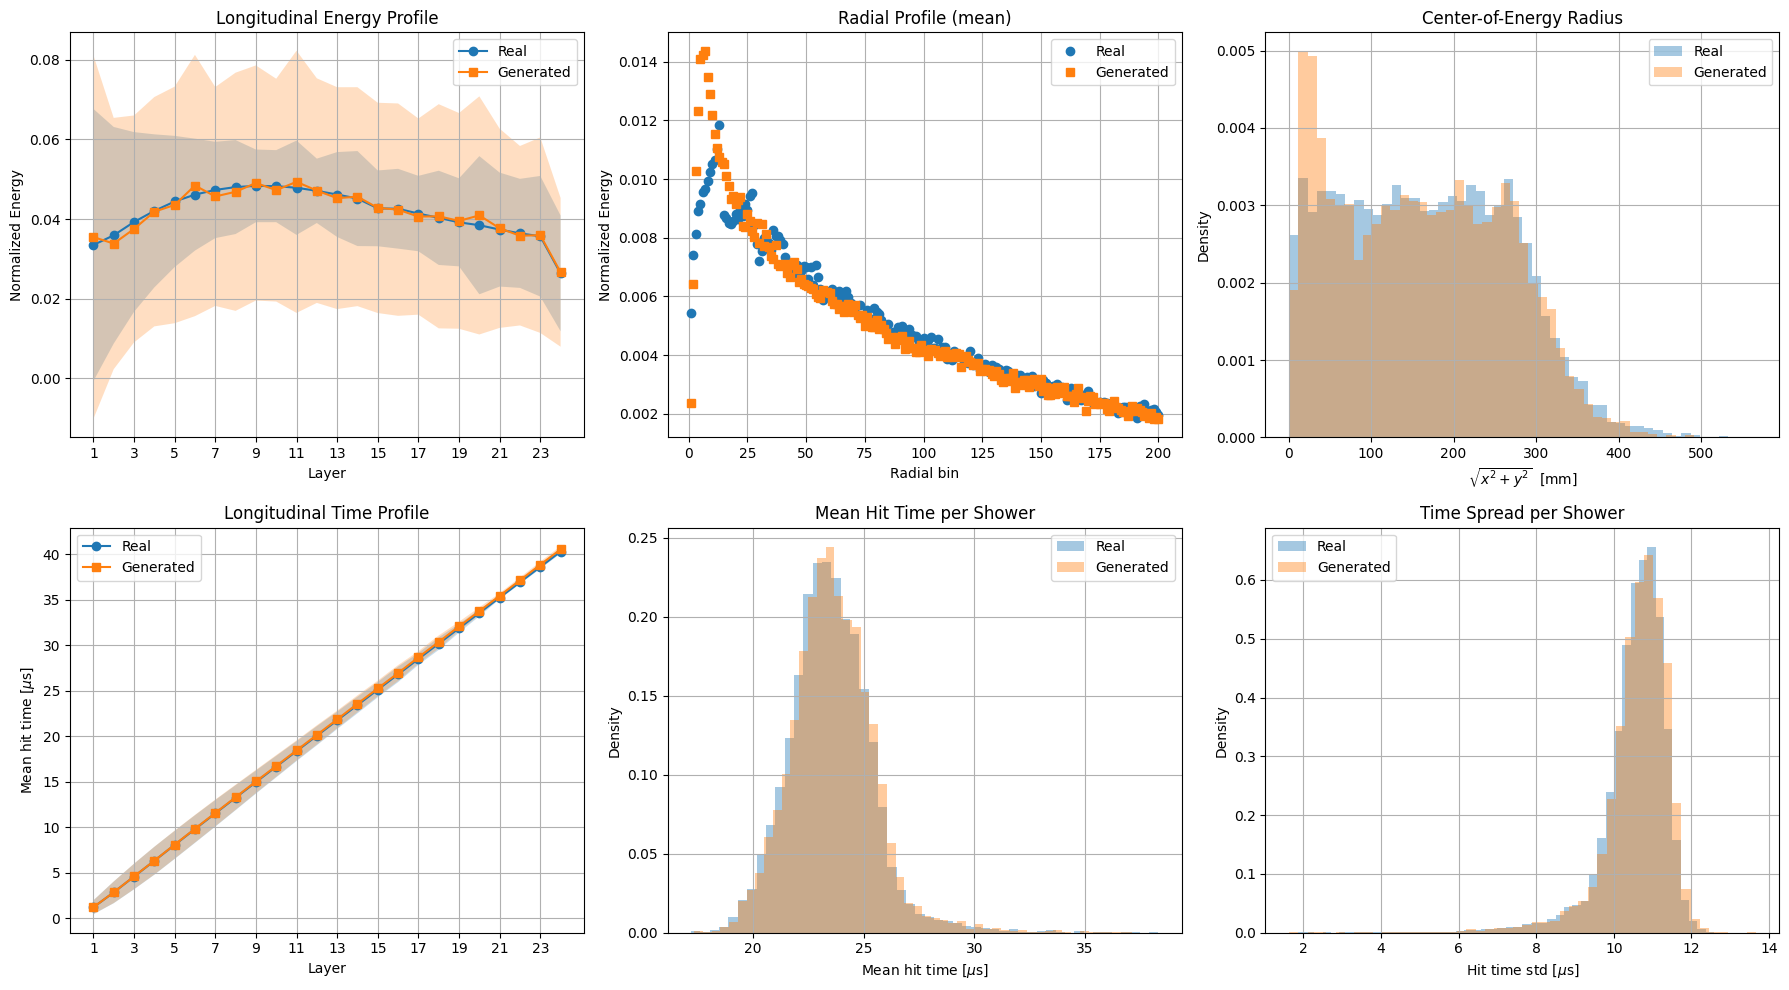

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

gen_file  = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"
real_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"


def load_obs(path):
    with h5py.File(path, "r") as f:
        layer  = f["observables/energy_per_layer"][:]      # (N, 24)
        radial = f["observables/energy_per_radial_bin"][:] # (N, 200)
        center = f["observables/center_of_energy"][:]      # (N, 3)
    return layer, radial, center


def load_time_obs(path, num_layers=24):
    """Read raw variable-length shower arrays and compute time observables.

    Each entry in f["showers"] is a flat 1D array of length n_hits * ncols.
    ncols is read from f["shape"][:, 2] — 4 for (x,y,z,e), 5 for (x,y,z,e,t).
    """
    with h5py.File(path, "r") as f:
        raw   = f["showers"][:]   # object array of flat variable-length arrays
        shape = f["shape"][:]     # (N, 3): each row is (n_hits, 1, ncols) or similar

    ncols = int(shape[2])   # shape is 1D: [N, max_points, ncols]

    if ncols < 5:
        raise ValueError(
            f"{path} has {ncols} columns per hit — time feature (col 4) not present. "
            "Re-run with --with-time data."
        )

    N = len(raw)
    mean_t          = np.zeros(N, dtype=np.float64)
    std_t           = np.zeros(N, dtype=np.float64)
    time_per_layer  = np.zeros((N, num_layers), dtype=np.float64)
    count_per_layer = np.zeros((N, num_layers), dtype=np.float64)

    for i, flat in enumerate(raw):
        pts  = flat.reshape(-1, ncols)                                      # (n_hits, ncols)
        mask = pts[:, 3] > 0                                                # e > 0
        if mask.sum() == 0:
            continue
        t         = pts[mask, 4]                                            # valid hit times
        mean_t[i] = t.mean()
        std_t[i]  = t.std()

        layer_idx = np.clip(
            (pts[mask, 2] + 0.1).astype(np.int32), 0, num_layers - 1
        )
        np.add.at(time_per_layer[i],  layer_idx, t)
        np.add.at(count_per_layer[i], layer_idx, 1)

    mean_t_per_layer = time_per_layer / count_per_layer.clip(min=1)         # (N, num_layers)
    return mean_t, std_t, mean_t_per_layer


# ------------------------------------------------------------------ load ---
print("Loading energy observables...")
gen_layer,  gen_radial,  gen_center  = load_obs(gen_file)
real_layer, real_radial, real_center = load_obs(real_file)

print("Loading time observables (looping over showers, may take a moment)...")
gen_mean_t,  gen_std_t,  gen_t_layer  = load_time_obs(gen_file)
real_mean_t, real_std_t, real_t_layer = load_time_obs(real_file)
print("Done.")

# ------------------------------------------------- normalize energy -------
gen_layer   = gen_layer  / gen_layer.sum(axis=1,  keepdims=True)
real_layer  = real_layer / real_layer.sum(axis=1, keepdims=True)
gen_radial  = gen_radial / gen_radial.sum(axis=1, keepdims=True)
real_radial = real_radial / real_radial.sum(axis=1, keepdims=True)

# ------------------------------------------------- summary stats ----------
layers = np.arange(1, 25)
rbins  = np.arange(1, gen_radial.shape[1] + 1)

gL_m, gL_s = gen_layer.mean(0),   gen_layer.std(0)
rL_m, rL_s = real_layer.mean(0),  real_layer.std(0)

gR_m = gen_radial.mean(0)
rR_m = real_radial.mean(0)

gC_r = np.sqrt(gen_center[:,  0]**2 + gen_center[:,  1]**2)
rC_r = np.sqrt(real_center[:, 0]**2 + real_center[:, 1]**2)

gTL_m, gTL_s = gen_t_layer.mean(0),   gen_t_layer.std(0)
rTL_m, rTL_s = real_t_layer.mean(0),  real_t_layer.std(0)

US = 1e6   # seconds → microseconds

# --------------------------------------------------------- 2×3 figure -----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Longitudinal energy profile
ax = axes[0, 0]
ax.plot(layers, rL_m, marker='o', label="Real")
ax.fill_between(layers, rL_m - rL_s, rL_m + rL_s, alpha=0.25)
ax.plot(layers, gL_m, marker='s', label="Generated")
ax.fill_between(layers, gL_m - gL_s, gL_m + gL_s, alpha=0.25)
ax.set_xlabel("Layer")
ax.set_ylabel("Normalized Energy")
ax.set_title("Longitudinal Energy Profile")
ax.set_xticks(np.arange(1, 25, 2))
ax.grid(True)
ax.legend()

# (2) Radial energy profile
ax = axes[0, 1]
ax.plot(rbins, rR_m, marker='o', linestyle='None', label="Real")
ax.plot(rbins, gR_m, marker='s', linestyle='None', label="Generated")
ax.set_xlabel("Radial bin")
ax.set_ylabel("Normalized Energy")
ax.set_title("Radial Profile (mean)")
ax.grid(True)
ax.legend()

# (3) Center-of-energy radius
ax = axes[0, 2]
ax.hist(rC_r, bins=50, density=True, alpha=0.4, label="Real")
ax.hist(gC_r, bins=50, density=True, alpha=0.4, label="Generated")
ax.set_xlabel(r"$\sqrt{x^2+y^2}$  [mm]")
ax.set_ylabel("Density")
ax.set_title("Center-of-Energy Radius")
ax.grid(True)
ax.legend()

# (4) Longitudinal time profile
ax = axes[1, 0]
ax.plot(layers, rTL_m * US, marker='o', label="Real")
ax.fill_between(layers,
                (rTL_m - rTL_s) * US,
                (rTL_m + rTL_s) * US, alpha=0.25)
ax.plot(layers, gTL_m * US, marker='s', label="Generated")
ax.fill_between(layers,
                (gTL_m - gTL_s) * US,
                (gTL_m + gTL_s) * US, alpha=0.25)
ax.set_xlabel("Layer")
ax.set_ylabel(r"Mean hit time [$\mu$s]")
ax.set_title("Longitudinal Time Profile")
ax.set_xticks(np.arange(1, 25, 2))
ax.grid(True)
ax.legend()

# (5) Mean hit time per shower
ax = axes[1, 1]
ax.hist(real_mean_t * US, bins=50, density=True, alpha=0.4, label="Real")
ax.hist(gen_mean_t  * US, bins=50, density=True, alpha=0.4, label="Generated")
ax.set_xlabel(r"Mean hit time [$\mu$s]")
ax.set_ylabel("Density")
ax.set_title("Mean Hit Time per Shower")
ax.grid(True)
ax.legend()

# (6) Time spread per shower
ax = axes[1, 2]
ax.hist(real_std_t * US, bins=50, density=True, alpha=0.4, label="Real")
ax.hist(gen_std_t  * US, bins=50, density=True, alpha=0.4, label="Generated")
ax.set_xlabel(r"Hit time std [$\mu$s]")
ax.set_ylabel("Density")
ax.set_title("Time Spread per Shower")
ax.grid(True)
ax.legend()

plt.tight_layout()
out = "shower_observables.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved to {out}")
plt.show()

Loading AllShowers file...
Loading Corsika file...
Computing time observables (AllShowers)...
Computing time observables (Corsika)...
Done.
Saved → shower_observables_by_pdg.png


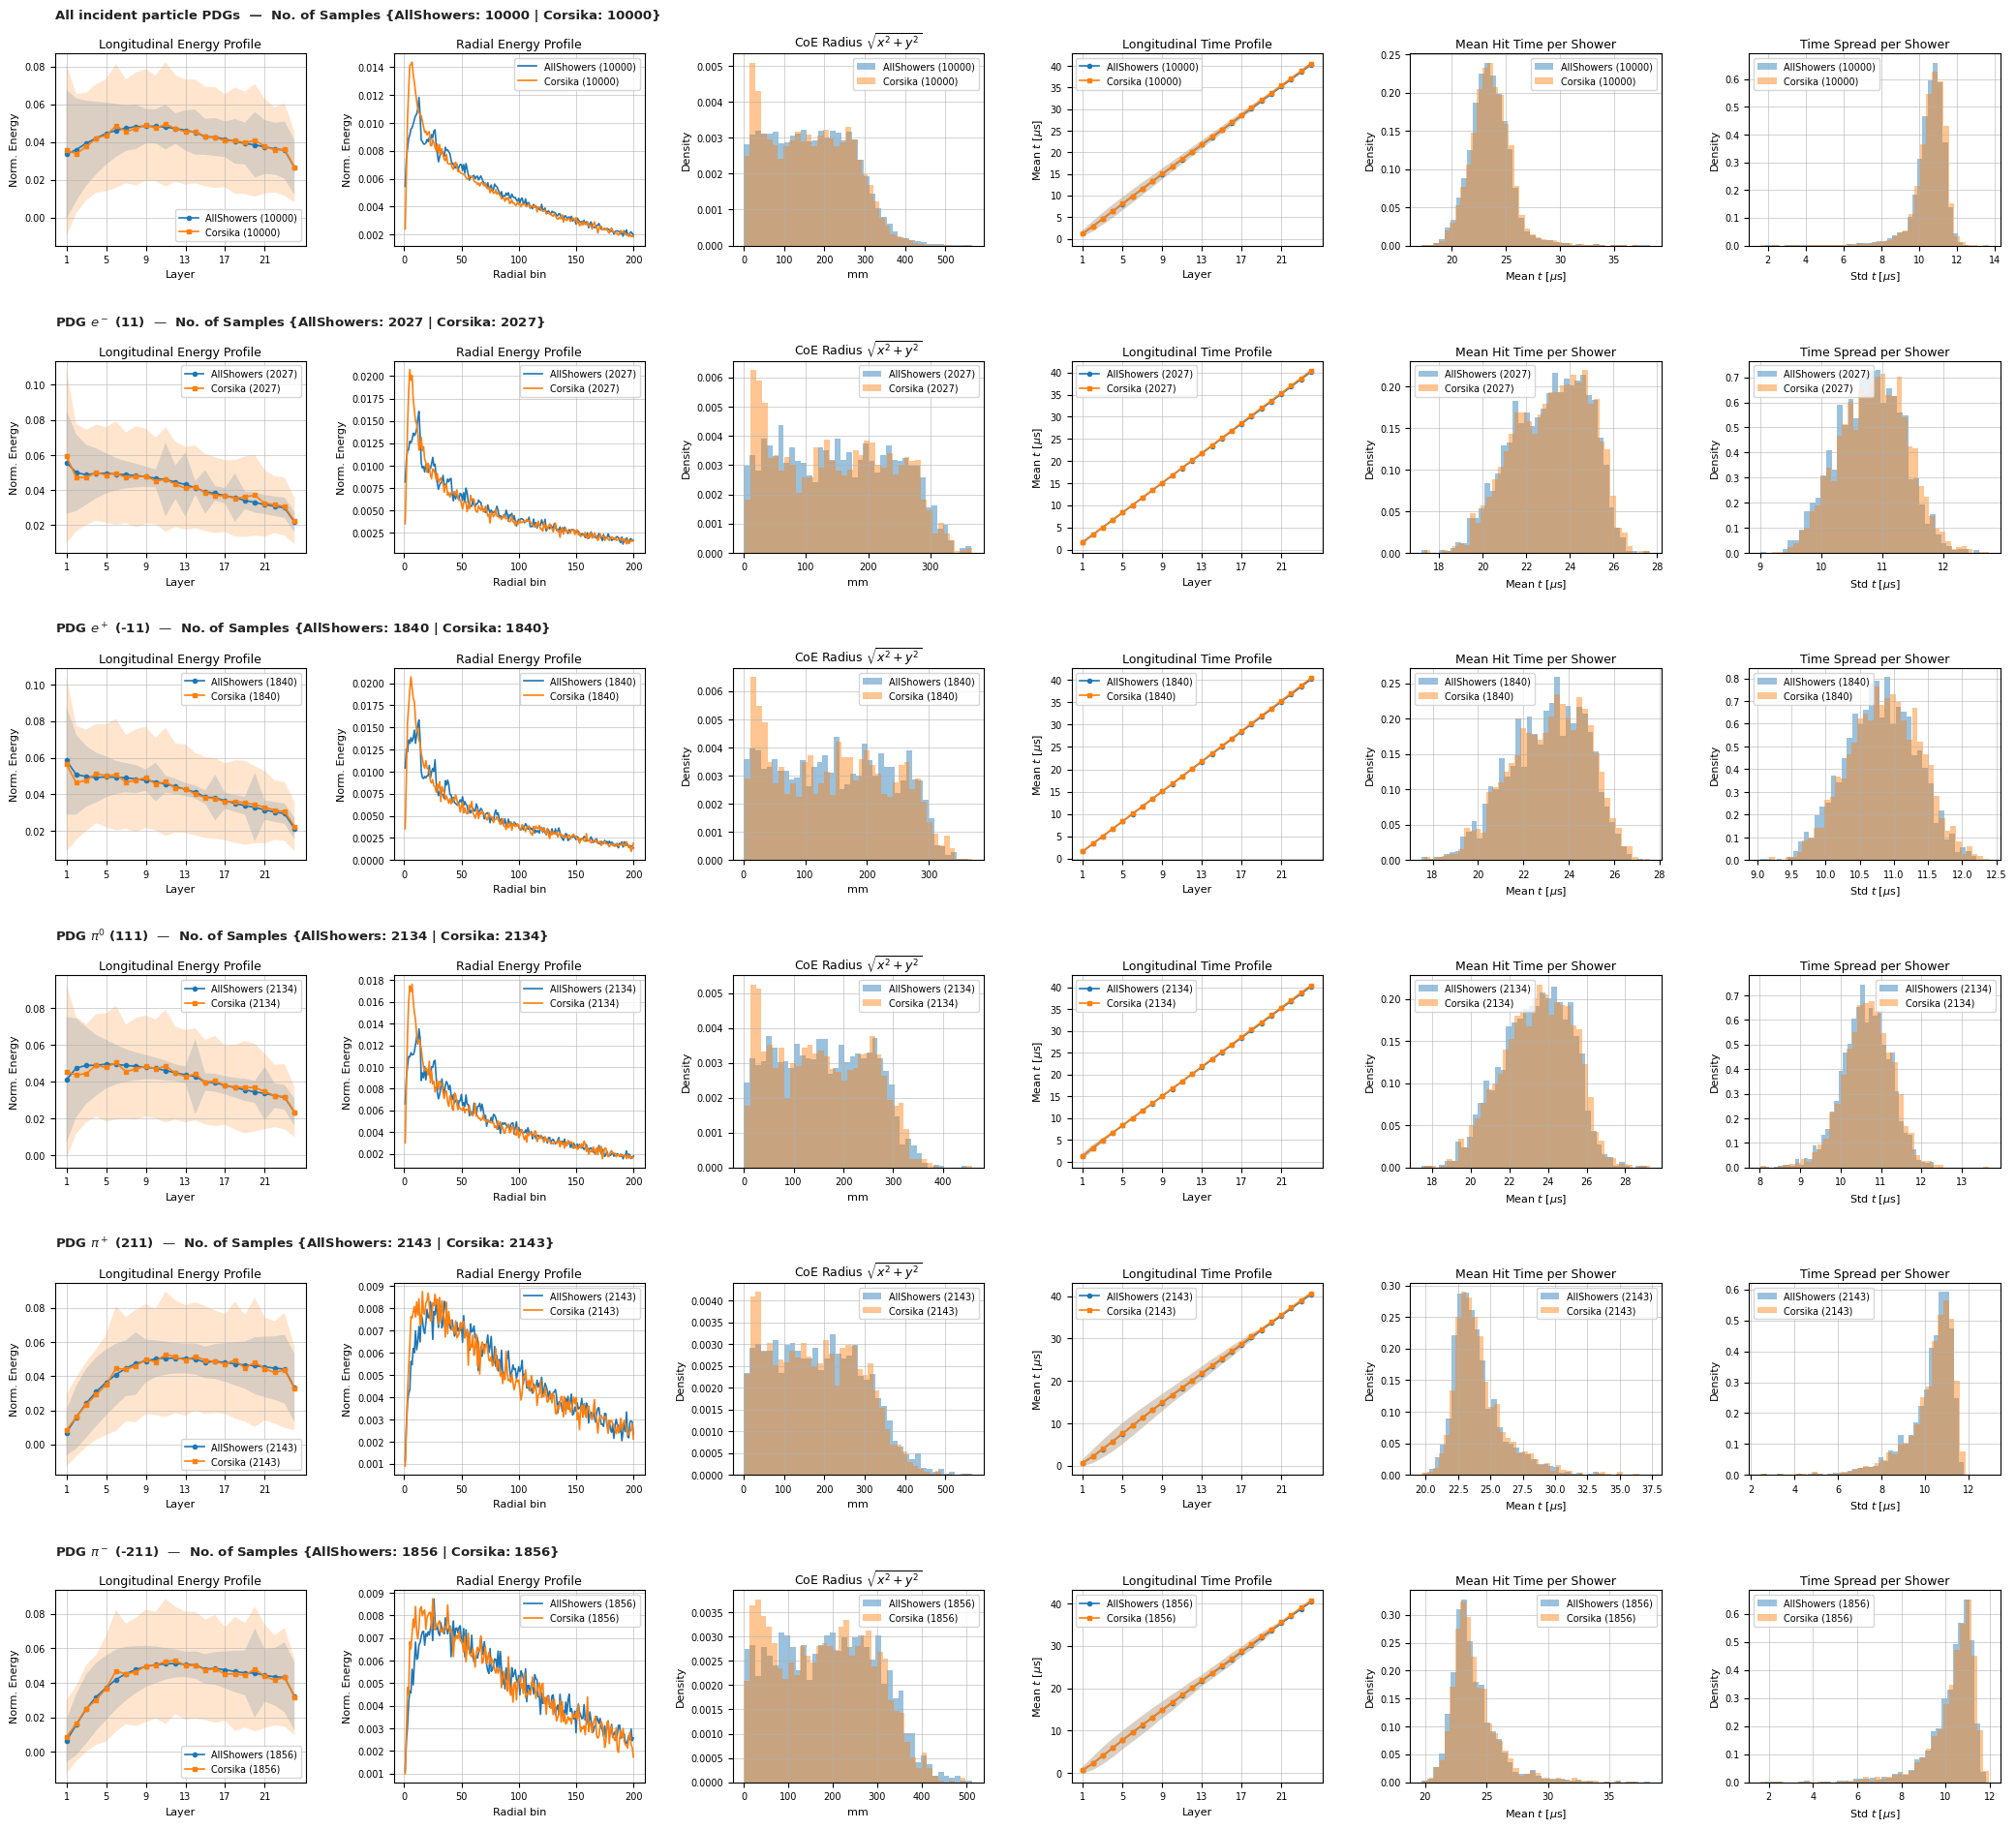

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

gen_file  = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"
real_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"

PDG_NAMES = {11: r"$e^-$", -11: r"$e^+$", 111: r"$\pi^0$", 211: r"$\pi^+$", -211: r"$\pi^-$"}
NUM_LAYERS = 24
US = 1e6   # seconds -> microseconds


# ------------------------------------------------------------------ loaders

def load_all(path):
    """Load energy observables, PDG labels, and raw showers for time."""
    with h5py.File(path, "r") as f:
        layer  = f["observables/energy_per_layer"][:]       # (N, 24)
        radial = f["observables/energy_per_radial_bin"][:]  # (N, 200)
        center = f["observables/center_of_energy"][:]       # (N, 3)
        pdg    = f["pdg"][:]                                # (N,)
        raw    = f["showers"][:]                            # (N,) object array
        shape  = f["shape"][:]                              # 1D: [N, max_pts, ncols]
    ncols = int(shape[2])
    return layer, radial, center, pdg, raw, ncols


def compute_time_obs(raw, ncols, num_layers=NUM_LAYERS):
    """Compute per-shower time observables from raw variable-length arrays."""
    if ncols < 5:
        raise ValueError(f"ncols={ncols} — no time feature (col 4).")
    N = len(raw)
    mean_t          = np.zeros(N, dtype=np.float64)
    std_t           = np.zeros(N, dtype=np.float64)
    time_per_layer  = np.zeros((N, num_layers), dtype=np.float64)
    count_per_layer = np.zeros((N, num_layers), dtype=np.float64)

    for i, flat in enumerate(raw):
        pts = flat.reshape(-1, ncols)
        mask = pts[:, 3] > 0
        if mask.sum() == 0:
            continue

        t = pts[mask, 4]
        mean_t[i] = t.mean()
        std_t[i] = t.std()

        layer_idx = np.clip((pts[mask, 2] + 0.1).astype(np.int32), 0, num_layers - 1)
        np.add.at(time_per_layer[i], layer_idx, t)
        np.add.at(count_per_layer[i], layer_idx, 1)

    mean_t_per_layer = time_per_layer / count_per_layer.clip(min=1)
    return mean_t, std_t, mean_t_per_layer


# ------------------------------------------------------------------ load

print("Loading AllShowers file...")
r_layer, r_radial, r_center, r_pdg, r_raw, r_ncols = load_all(real_file)

print("Loading Corsika file...")
g_layer, g_radial, g_center, g_pdg, g_raw, g_ncols = load_all(gen_file)

print("Computing time observables (AllShowers)...")
r_mean_t, r_std_t, r_t_layer = compute_time_obs(r_raw, r_ncols)

print("Computing time observables (Corsika)...")
g_mean_t, g_std_t, g_t_layer = compute_time_obs(g_raw, g_ncols)

print("Done.")

# normalize energy per shower
r_layer  = r_layer  / r_layer.sum(1, keepdims=True)
g_layer  = g_layer  / g_layer.sum(1, keepdims=True)
r_radial = r_radial / r_radial.sum(1, keepdims=True)
g_radial = g_radial / g_radial.sum(1, keepdims=True)

layers = np.arange(1, NUM_LAYERS + 1)
rbins  = np.arange(1, r_radial.shape[1] + 1)

# Row 0 = All, then one row per PDG found in generated file
pdgs_in_data = sorted(np.unique(r_pdg).tolist(), key=lambda x: (abs(x), -x))
row_configs  = [("All", None)] + [(PDG_NAMES.get(p, str(p)), p) for p in pdgs_in_data]

NCOLS = 6
col_titles = [
    "Longitudinal Energy Profile",
    "Radial Energy Profile",
    r"CoE Radius $\sqrt{x^2+y^2}$",
    "Longitudinal Time Profile",
    "Mean Hit Time per Shower",
    "Time Spread per Shower",
]
col_xlabels = [
    "Layer",
    "Radial bin",
    "mm",
    "Layer",
    r"Mean $t$ [$\mu$s]",
    r"Std $t$ [$\mu$s]",
]


# ------------------------------------------------------------------ helpers

def mask_for(pdg_arr, pdg_val):
    return np.ones(len(pdg_arr), dtype=bool) if pdg_val is None else pdg_arr == pdg_val


def plot_row(axes, r_mask, g_mask, n_real, n_gen):
    rl  = r_layer[r_mask]
    gl  = g_layer[g_mask]
    rr  = r_radial[r_mask]
    gr  = g_radial[g_mask]
    rc  = r_center[r_mask]
    gc  = g_center[g_mask]
    rtl = r_t_layer[r_mask]
    gtl = g_t_layer[g_mask]
    rmt = r_mean_t[r_mask]
    gmt = g_mean_t[g_mask]
    rst = r_std_t[r_mask]
    gst = g_std_t[g_mask]

    rLm, rLs = rl.mean(0), rl.std(0)
    gLm, gLs = gl.mean(0), gl.std(0)
    rTm, rTs = rtl.mean(0), rtl.std(0)
    gTm, gTs = gtl.mean(0), gtl.std(0)

    rCr = np.sqrt(rc[:, 0]**2 + rc[:, 1]**2)
    gCr = np.sqrt(gc[:, 0]**2 + gc[:, 1]**2)

    allshowers_label = f"AllShowers ({n_real})"
    corsika_label    = f"Corsika ({n_gen})"

    # (0) Longitudinal energy
    ax = axes[0]
    ax.plot(layers, rLm, marker='o', ms=3, lw=1.2, label=allshowers_label)
    ax.fill_between(layers, rLm - rLs, rLm + rLs, alpha=0.2)
    ax.plot(layers, gLm, marker='s', ms=3, lw=1.2, label=corsika_label)
    ax.fill_between(layers, gLm - gLs, gLm + gLs, alpha=0.2)
    ax.set_xticks(np.arange(1, 25, 4))
    ax.grid(True, lw=0.4)
    ax.legend(fontsize=7)

    # (1) Radial energy
    ax = axes[1]
    ax.plot(rbins, rr.mean(0), lw=1.2, label=allshowers_label)
    ax.plot(rbins, gr.mean(0), lw=1.2, label=corsika_label)
    ax.grid(True, lw=0.4)
    ax.legend(fontsize=7)

    # (2) Center-of-energy radius
    ax = axes[2]
    ax.hist(rCr, bins=40, density=True, alpha=0.45, label=allshowers_label)
    ax.hist(gCr, bins=40, density=True, alpha=0.45, label=corsika_label)
    ax.grid(True, lw=0.4)
    ax.legend(fontsize=7)

    # (3) Longitudinal time profile
    ax = axes[3]
    ax.plot(layers, rTm * US, marker='o', ms=3, lw=1.2, label=allshowers_label)
    ax.fill_between(layers, (rTm - rTs) * US, (rTm + rTs) * US, alpha=0.2)
    ax.plot(layers, gTm * US, marker='s', ms=3, lw=1.2, label=corsika_label)
    ax.fill_between(layers, (gTm - gTs) * US, (gTm + gTs) * US, alpha=0.2)
    ax.set_xticks(np.arange(1, 25, 4))
    ax.grid(True, lw=0.4)
    ax.legend(fontsize=7)

    # (4) Mean hit time distribution
    ax = axes[4]
    ax.hist(rmt * US, bins=40, density=True, alpha=0.45, label=allshowers_label)
    ax.hist(gmt * US, bins=40, density=True, alpha=0.45, label=corsika_label)
    ax.grid(True, lw=0.4)
    ax.legend(fontsize=7)

    # (5) Time spread distribution
    ax = axes[5]
    ax.hist(rst * US, bins=40, density=True, alpha=0.45, label=allshowers_label)
    ax.hist(gst * US, bins=40, density=True, alpha=0.45, label=corsika_label)
    ax.grid(True, lw=0.4)
    ax.legend(fontsize=7)


# ------------------------------------------------------------------ figure

NROWS = len(row_configs)
fig = plt.figure(figsize=(NCOLS * 3.6, NROWS * 3.2))
gs = gridspec.GridSpec(
    NROWS, NCOLS,
    figure=fig,
    hspace=0.6, wspace=0.35,
    top=0.97, bottom=0.04, left=0.06, right=0.99,
)

for row_i, (row_label, pdg_val) in enumerate(row_configs):
    r_mask = mask_for(r_pdg, pdg_val)
    g_mask = mask_for(g_pdg, pdg_val)
    n_real = int(r_mask.sum())
    n_gen  = int(g_mask.sum())

    axes = [fig.add_subplot(gs[row_i, c]) for c in range(NCOLS)]
    plot_row(axes, r_mask, g_mask, n_real, n_gen)

    header = (
        f"{'All incident particle PDGs' if pdg_val is None else f'PDG {row_label} ({pdg_val})'}"
        f"  —  No. of Samples {{AllShowers: {n_real} | Corsika: {n_gen}}}"
    )
    axes[0].annotate(
        header,
        xy=(0, 1.18), xycoords="axes fraction",
        fontsize=9.5, fontweight="bold", color="#222222",
    )

    for ax in axes:
        ax.tick_params(labelsize=7)

    axes[0].set_ylabel("Norm. Energy", fontsize=8)
    axes[1].set_ylabel("Norm. Energy", fontsize=8)
    axes[2].set_ylabel("Density", fontsize=8)
    axes[3].set_ylabel(r"Mean $t$ [$\mu$s]", fontsize=8)
    axes[4].set_ylabel("Density", fontsize=8)
    axes[5].set_ylabel("Density", fontsize=8)

    for c, ax in enumerate(axes):
        ax.set_xlabel(col_xlabels[c], fontsize=8)
        ax.set_title(col_titles[c], fontsize=9, pad=4)

out = "shower_observables_by_pdg.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Muon last epoch: 60
Ranger last epoch: 121
Plotting until epoch: 60


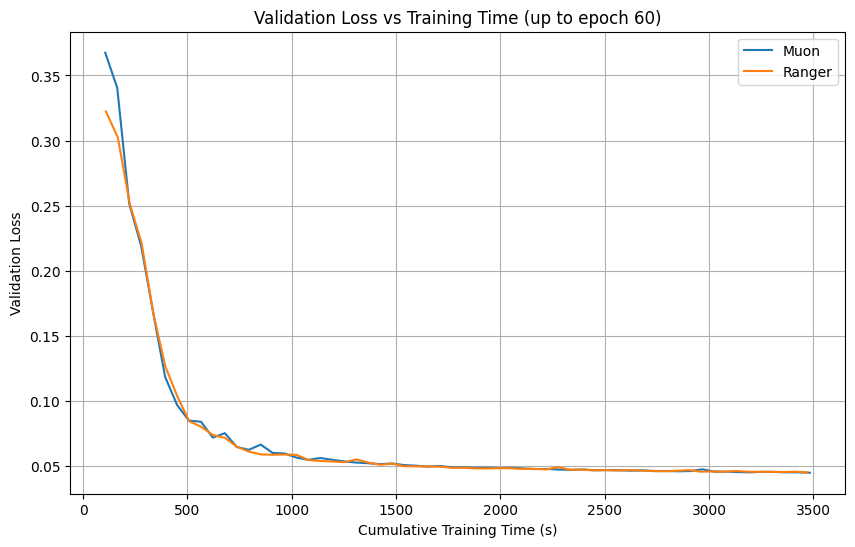

In [14]:
import re
import numpy as np
import matplotlib.pyplot as plt

muon_log = "/n/home04/hhanif/AllShowers/results/20260307_101304_CNF-Transformer/log/train_64561602.out"
ranger_log = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/log/train_64552169.out"


def parse_log(path):
    with open(path) as f:
        text = f.read()

    pattern = re.compile(
        r"=+\s*epoch\s+(\d+)\s*=+\s*"
        r"time:\s*([0-9.]+)s\s*"
        r"train loss:\s*([0-9.eE+-]+)\s*"
        r"validation loss:\s*([0-9.eE+-]+)"
    )

    epochs, times, train, val = [], [], [], []

    for m in pattern.finditer(text):
        epochs.append(int(m.group(1)))
        times.append(float(m.group(2)))
        train.append(float(m.group(3)))
        val.append(float(m.group(4)))

    return {
        "epoch": np.array(epochs),
        "time": np.array(times),
        "train": np.array(train),
        "val": np.array(val),
    }


muon = parse_log(muon_log)
ranger = parse_log(ranger_log)

# last epoch in each log
muon_last_epoch = muon["epoch"].max()
ranger_last_epoch = ranger["epoch"].max()

# common cutoff
cut_epoch = min(muon_last_epoch, ranger_last_epoch)

print("Muon last epoch:", muon_last_epoch)
print("Ranger last epoch:", ranger_last_epoch)
print("Plotting until epoch:", cut_epoch)

# masks
muon_mask = muon["epoch"] <= cut_epoch
ranger_mask = ranger["epoch"] <= cut_epoch

# cumulative training time
muon_time = np.cumsum(muon["time"][muon_mask])
ranger_time = np.cumsum(ranger["time"][ranger_mask])

plt.figure(figsize=(10,6))

plt.plot(muon_time, muon["val"][muon_mask], label="Muon")
plt.plot(ranger_time, ranger["val"][ranger_mask], label="Ranger")

plt.xlabel("Cumulative Training Time (s)")
plt.ylabel("Validation Loss")
plt.title(f"Validation Loss vs Training Time (up to epoch {cut_epoch})")

plt.grid(True)
plt.legend()
plt.show()

In [15]:
import re
import numpy as np

ranger_log = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/log/train_64552169.out"


def parse_log(path):
    with open(path, "r") as f:
        text = f.read()

    pattern = re.compile(
        r"=+\s*epoch\s+(\d+)\s*=+\s*"
        r"time:\s*([0-9.]+)s\s*"
        r"train loss:\s*([0-9.eE+-]+)\s*"
        r"validation loss:\s*([0-9.eE+-]+)"
    )

    epochs, times, train_losses, val_losses = [], [], [], []

    for m in pattern.finditer(text):
        epochs.append(int(m.group(1)))
        times.append(float(m.group(2)))
        train_losses.append(float(m.group(3)))
        val_losses.append(float(m.group(4)))

    return {
        "epoch": np.array(epochs),
        "time": np.array(times),
        "train_loss": np.array(train_losses),
        "val_loss": np.array(val_losses),
    }


def early_stopping_epoch(epochs, val_losses, patience=20, min_delta=0.0):
    """
    Returns:
      best_epoch: epoch with lowest validation loss
      stop_epoch: epoch at which early stopping would trigger
                  None if it never triggers
    """
    best_val = float("inf")
    best_epoch = None
    wait = 0
    stop_epoch = None

    for epoch, val in zip(epochs, val_losses):
        if val < best_val - min_delta:
            best_val = val
            best_epoch = epoch
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            stop_epoch = epoch
            break

    return best_epoch, best_val, stop_epoch


data = parse_log(ranger_log)

# best epoch directly from minimum validation loss
best_idx = np.argmin(data["val_loss"])
best_epoch = data["epoch"][best_idx]
best_val = data["val_loss"][best_idx]

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val:.6f}")

# early stopping estimate
patience = 20
min_delta = 0.0

es_best_epoch, es_best_val, stop_epoch = early_stopping_epoch(
    data["epoch"], data["val_loss"], patience=patience, min_delta=min_delta
)

print(f"\nUsing early stopping with patience={patience}, min_delta={min_delta}:")
print(f"Best checkpoint epoch: {es_best_epoch}")
if stop_epoch is not None:
    print(f"Training would stop at epoch: {stop_epoch}")
    print(f"Last useful epoch to keep: {es_best_epoch}")
else:
    print("Early stopping would not have triggered within the available log.")
    print(f"Last available epoch in log: {data['epoch'][-1]}")

Best epoch: 119
Best validation loss: 0.040700

Using early stopping with patience=20, min_delta=0.0:
Best checkpoint epoch: 119
Early stopping would not have triggered within the available log.
Last available epoch in log: 121


Loading CORSIKA (real)...
Loading AllShowers timesteps=16...
Loading AllShowers timesteps=32...
Loading AllShowers timesteps=64...
Done.
Saved -> shower_timestep_comparison.png


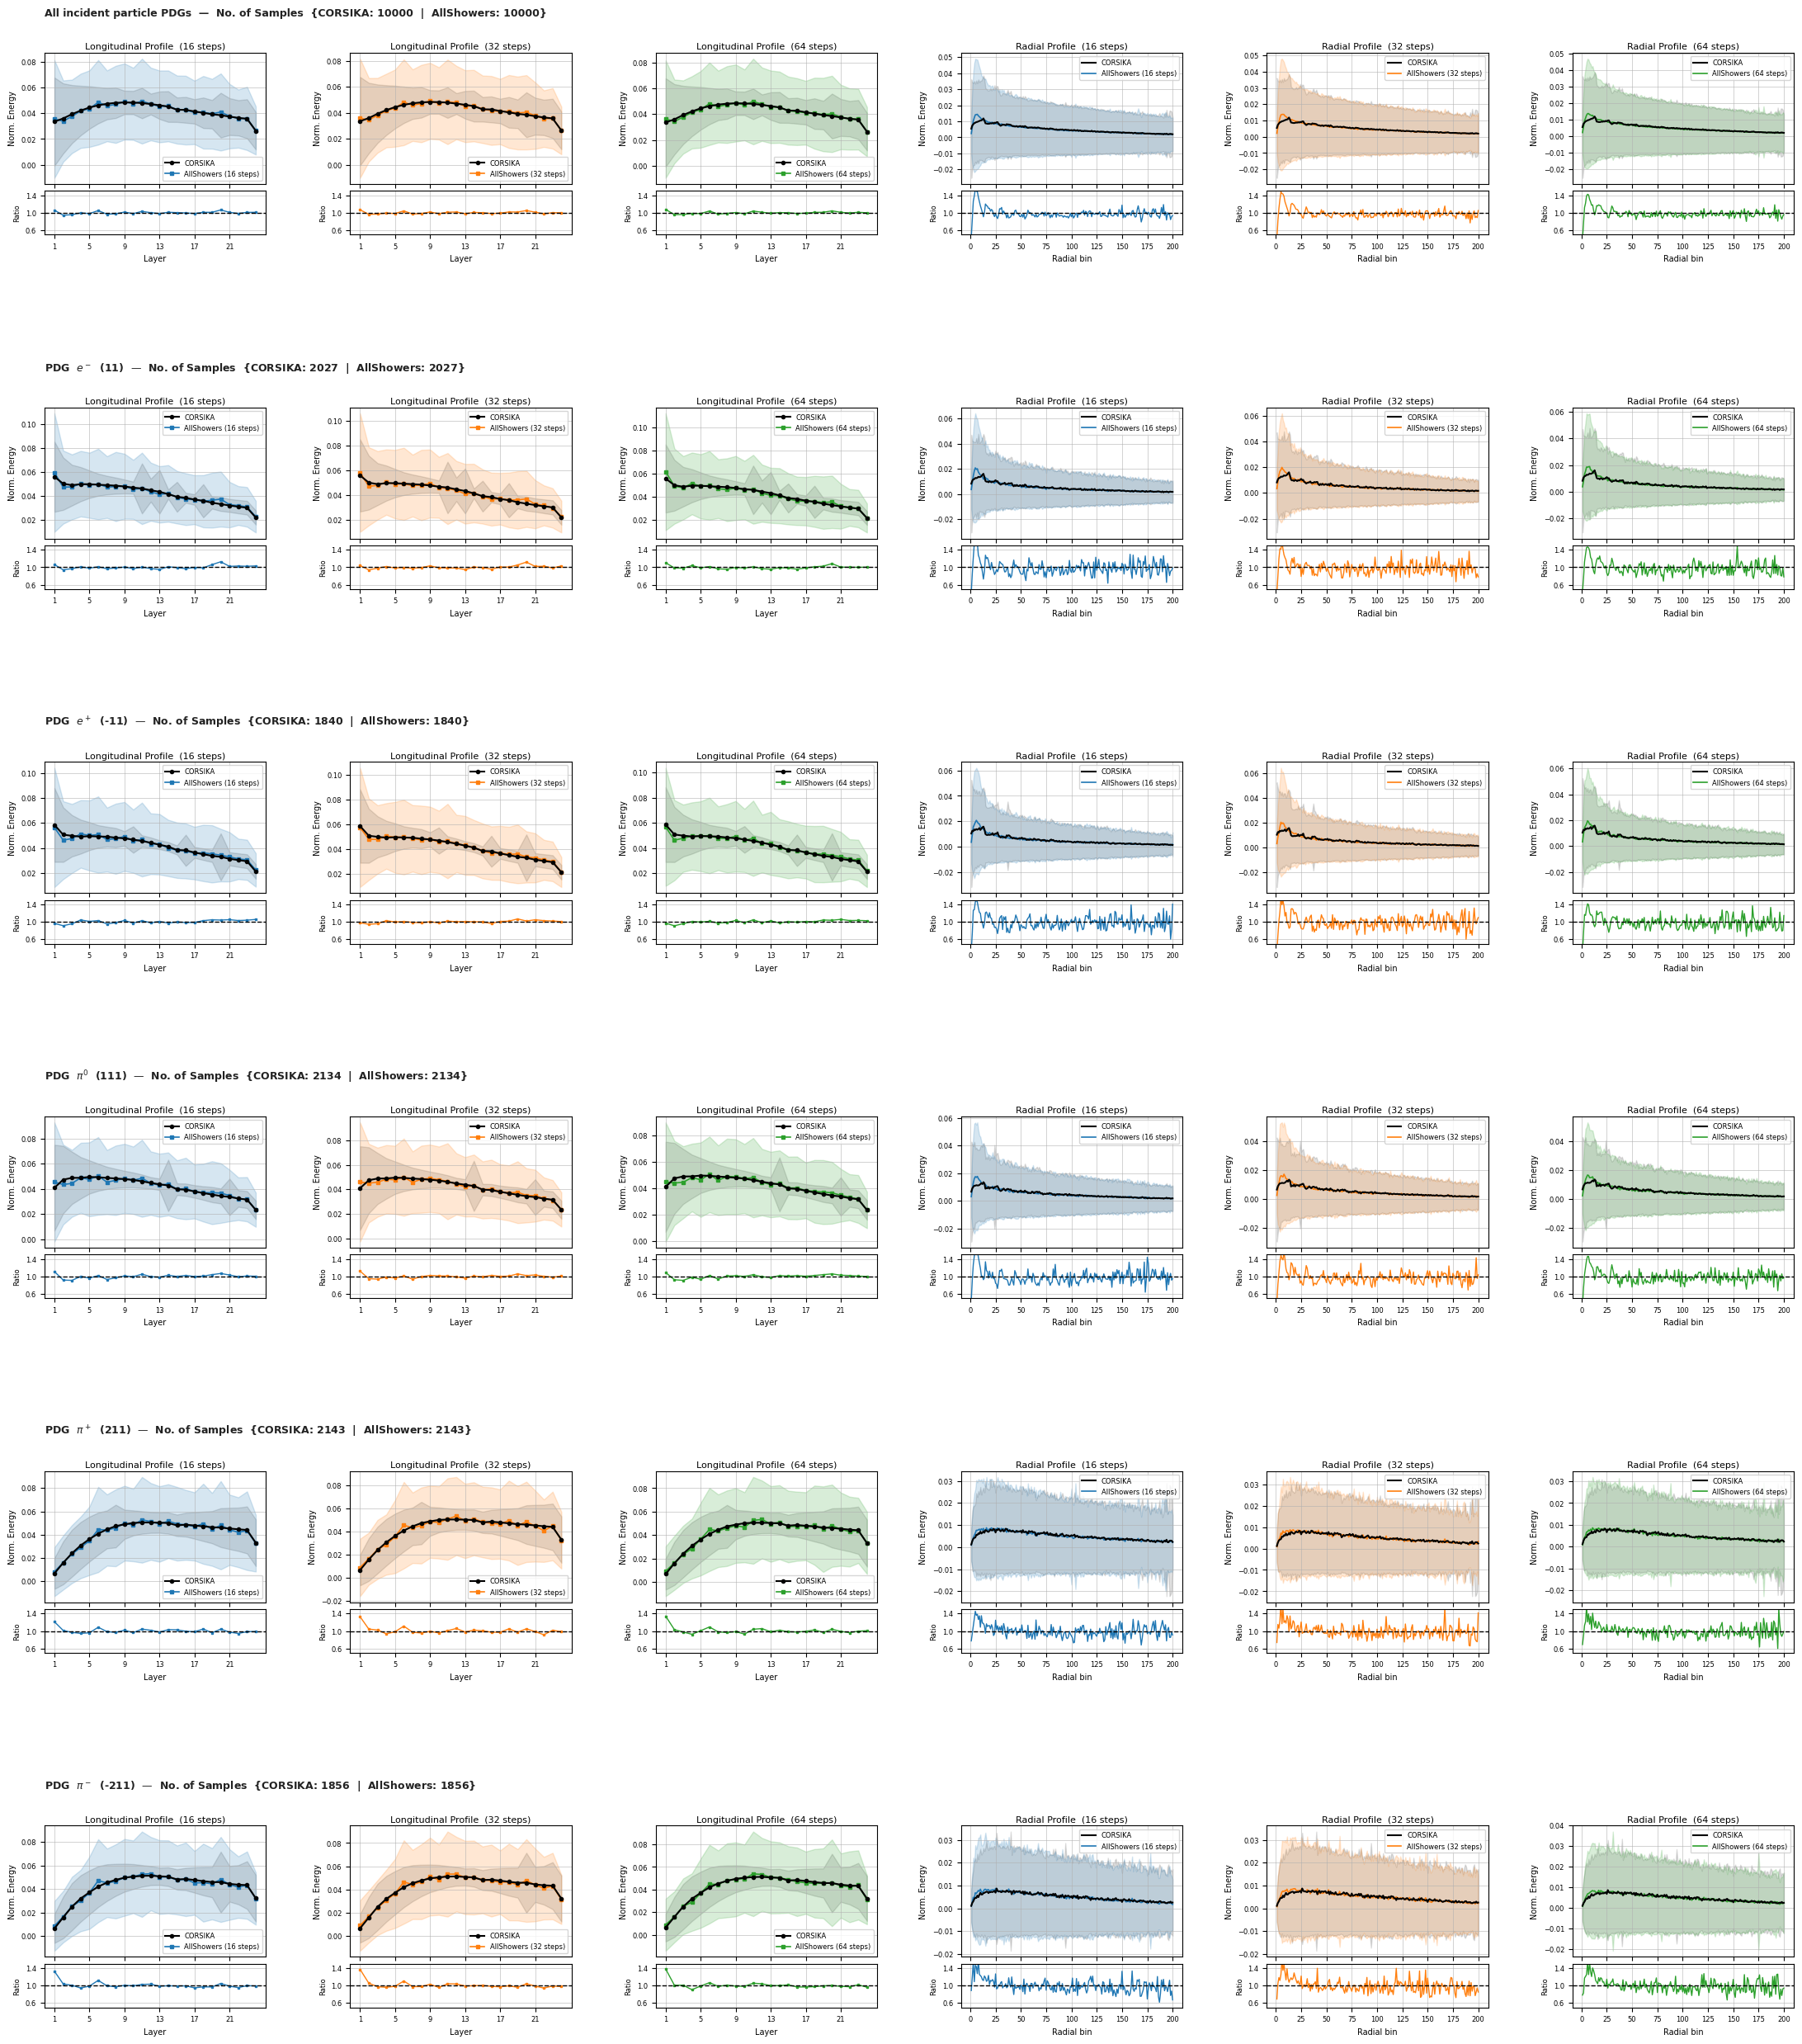

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

real_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"

gen_files = [
    ("/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5", 16),
    ("/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples01.h5", 32),
    ("/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples02.h5", 64),
]

PDG_NAMES  = {11: r"$e^-$", -11: r"$e^+$", 111: r"$\pi^0$", 211: r"$\pi^+$", -211: r"$\pi^-$"}
NUM_LAYERS = 24
REAL_LABEL = "CORSIKA"
GEN_LABEL  = "AllShowers"
COLORS     = ["C0", "C1", "C2"]


# ------------------------------------------------------------------ loaders

def load_obs(path):
    with h5py.File(path, "r") as f:
        layer  = f["observables/energy_per_layer"][:]
        radial = f["observables/energy_per_radial_bin"][:]
        pdg    = f["pdg"][:]
    layer  = layer  / layer.sum(1,  keepdims=True)
    radial = radial / radial.sum(1, keepdims=True)
    return layer, radial, pdg


# ------------------------------------------------------------------ load

print("Loading CORSIKA (real)...")
r_layer, r_radial, r_pdg = load_obs(real_file)

gen_data = []
for path, nsteps in gen_files:
    print(f"Loading AllShowers timesteps={nsteps}...")
    gl, gr, gp = load_obs(path)
    gen_data.append({"layer": gl, "radial": gr, "pdg": gp, "nsteps": nsteps})
print("Done.")

# PDG rows
pdgs_in_data = sorted(np.unique(r_pdg).tolist(), key=lambda x: (abs(x), -x))
row_configs  = [("All", None)] + [(PDG_NAMES.get(p, str(p)), p) for p in pdgs_in_data]

layers = np.arange(1, NUM_LAYERS + 1)
rbins  = np.arange(1, r_radial.shape[1] + 1)


# ------------------------------------------------------------------ helpers

def mask_for(pdg_arr, pdg_val):
    return np.ones(len(pdg_arr), dtype=bool) if pdg_val is None else pdg_arr == pdg_val


# ------------------------------------------------------------------ figure
# 6 cols: 3 longitudinal + 3 radial
# Each cell = main axes (height 3) + ratio axes (height 1)

NROWS  = len(row_configs)
NCOLS  = 6

col_titles = (
    [f"Longitudinal Profile  ({d['nsteps']} steps)" for d in gen_data] +
    [f"Radial Profile  ({d['nsteps']} steps)"        for d in gen_data]
)

fig = plt.figure(figsize=(NCOLS * 3.8, NROWS * 4.2))

outer_gs = gridspec.GridSpec(
    NROWS, NCOLS,
    figure=fig,
    hspace=0.95, wspace=0.38,
    top=0.97, bottom=0.03, left=0.06, right=0.99,
)

for row_i, (row_label, pdg_val) in enumerate(row_configs):
    r_mask = mask_for(r_pdg, pdg_val)
    n_real = int(r_mask.sum())
    n_gen  = int(mask_for(gen_data[0]["pdg"], pdg_val).sum())

    header = (
        ("All incident particle PDGs" if pdg_val is None
         else f"PDG  {row_label}  ({pdg_val})")
        + f"  \u2014  No. of Samples  {{CORSIKA: {n_real}  |  AllShowers: {n_gen}}}"
    )

    main_axes  = []
    ratio_axes = []

    for col_i in range(NCOLS):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer_gs[row_i, col_i],
            height_ratios=[3, 1],
            hspace=0.08,
        )
        ax_main  = fig.add_subplot(inner[0])
        ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)
        plt.setp(ax_main.get_xticklabels(), visible=False)
        main_axes.append(ax_main)
        ratio_axes.append(ax_ratio)

    # row header
    main_axes[0].annotate(
        header,
        xy=(0, 1.28), xycoords="axes fraction",
        fontsize=9, fontweight="bold", color="#222222",
    )

    # longitudinal cols 0,1,2
    for col_i, d in enumerate(gen_data):
        g_mask = mask_for(d["pdg"], pdg_val)
        rLm = r_layer[r_mask].mean(0);  rLs = r_layer[r_mask].std(0)
        gLm = d["layer"][g_mask].mean(0); gLs = d["layer"][g_mask].std(0)

        ax = main_axes[col_i]
        ax.plot(layers, rLm, color="black", lw=1.5, marker='o', ms=3,
                label=REAL_LABEL, zorder=5)
        ax.fill_between(layers, rLm - rLs, rLm + rLs, color="black", alpha=0.12)
        ax.plot(layers, gLm, color=COLORS[col_i], lw=1.2, marker='s', ms=3,
                label=f"{GEN_LABEL} ({d['nsteps']} steps)")
        ax.fill_between(layers, gLm - gLs, gLm + gLs, color=COLORS[col_i], alpha=0.18)
        ax.set_title(col_titles[col_i], fontsize=8, pad=3)
        ax.set_ylabel("Norm. Energy", fontsize=7)
        ax.set_xticks(np.arange(1, 25, 4))
        ax.grid(True, lw=0.4)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=6)

        ratio = gLm / np.where(rLm > 0, rLm, np.nan)
        ar = ratio_axes[col_i]
        ar.plot(layers, ratio, color=COLORS[col_i], lw=1.0, marker='s', ms=2)
        ar.axhline(1.0, color="black", lw=1.0, ls="--")
        ar.set_ylim(0.5, 1.5)
        ar.set_yticks([0.6, 1.0, 1.4])
        ar.set_xticks(np.arange(1, 25, 4))
        ar.grid(True, lw=0.4)
        ar.set_xlabel("Layer", fontsize=7)
        ar.set_ylabel("Ratio", fontsize=6)
        ar.tick_params(labelsize=6)

    # radial cols 3,4,5
    for col_i, d in enumerate(gen_data):
        g_mask = mask_for(d["pdg"], pdg_val)
        rRm = r_radial[r_mask].mean(0); rRs = r_radial[r_mask].std(0)
        gRm = d["radial"][g_mask].mean(0); gRs = d["radial"][g_mask].std(0)

        ax = main_axes[col_i + 3]
        ax.plot(rbins, rRm, color="black", lw=1.5, label=REAL_LABEL, zorder=5)
        ax.fill_between(rbins, rRm - rRs, rRm + rRs, color="black", alpha=0.12)
        ax.plot(rbins, gRm, color=COLORS[col_i], lw=1.2,
                label=f"{GEN_LABEL} ({d['nsteps']} steps)")
        ax.fill_between(rbins, gRm - gRs, gRm + gRs, color=COLORS[col_i], alpha=0.18)
        ax.set_title(col_titles[col_i + 3], fontsize=8, pad=3)
        ax.set_ylabel("Norm. Energy", fontsize=7)
        ax.grid(True, lw=0.4)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=6)

        ratio = gRm / np.where(rRm > 0, rRm, np.nan)
        ar = ratio_axes[col_i + 3]
        ar.plot(rbins, ratio, color=COLORS[col_i], lw=1.0)
        ar.axhline(1.0, color="black", lw=1.0, ls="--")
        ar.set_ylim(0.5, 1.5)
        ar.set_yticks([0.6, 1.0, 1.4])
        ar.grid(True, lw=0.4)
        ar.set_xlabel("Radial bin", fontsize=7)
        ar.set_ylabel("Ratio", fontsize=6)
        ar.tick_params(labelsize=6)

out = "shower_timestep_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

real_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"
gen_file  = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"


def get_cell_energy(path):
    energies = []

    with h5py.File(path, "r") as f:
        showers = f["showers"]

        for s in showers:
            arr = np.array(s).reshape(-1,5)   # [x,y,z,e,t]
            energies.append(arr[:,3])         # energy column

    return np.concatenate(energies)


# ---------------------------------------------------------
# load energies
real_energy = get_cell_energy(real_file)
gen_energy  = get_cell_energy(gen_file)

# ---------------------------------------------------------
# log bins like calorimeter plots
bins = np.logspace(-1, 3, 120)

real_hist, edges = np.histogram(real_energy, bins=bins)
gen_hist,  _     = np.histogram(gen_energy,  bins=bins)

centers = 0.5 * (edges[1:] + edges[:-1])

# ---------------------------------------------------------
# plot
plt.figure(figsize=(6,5))

plt.step(centers, real_hist, where="mid", label="Geant4", linewidth=2)
plt.step(centers, gen_hist, where="mid", linestyle="--", label="AllShowers", linewidth=2)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Cell Energy [MeV]")
plt.ylabel("# Cells")
plt.legend()

plt.tight_layout()
plt.show()

Loading generated...
Loading real...
Using 220 showers for each sample.


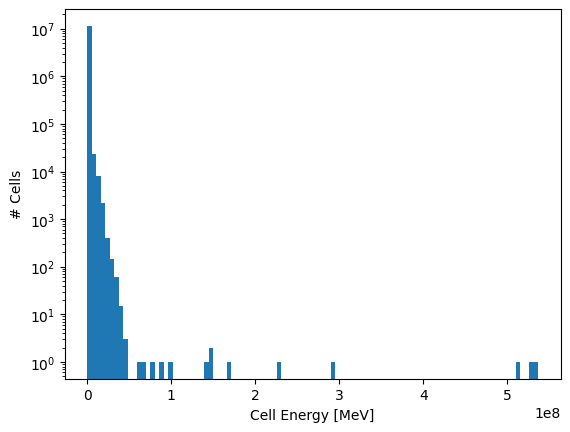

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"

all_energy = []

with h5py.File(path, "r") as f:
    showers = f["showers"]

    for s in showers:
        arr = np.array(s).reshape(-1,5)   # [x,y,z,e,t]
        e = arr[:,3]                      # energy column
        all_energy.append(e)

all_energy = np.concatenate(all_energy)

plt.hist(all_energy, bins=100, log=True)
plt.xlabel("Cell Energy [MeV]")
plt.ylabel("# Cells")
plt.show()

Loading CORSIKA showers...
Loading AllShowers...


/tmp/ipykernel_3505708/283168715.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


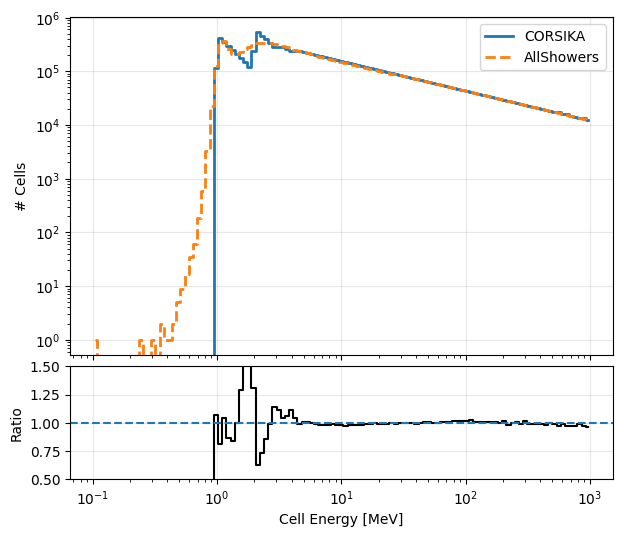

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

corsika_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"
allshowers_file = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"


# ---------------------------------------------------------
# function to read cell energies
def get_cell_energy(path):

    energies = []

    with h5py.File(path, "r") as f:
        showers = f["showers"]

        for s in showers:
            arr = np.array(s).reshape(-1,5)   # [x,y,z,e,t]
            energies.append(arr[:,3])         # energy column

    return np.concatenate(energies)


# ---------------------------------------------------------
print("Loading CORSIKA showers...")
corsika_energy = get_cell_energy(corsika_file)

print("Loading AllShowers...")
allshowers_energy = get_cell_energy(allshowers_file)


# ---------------------------------------------------------
# logarithmic bins
bins = np.logspace(-1, 3, 120)

corsika_hist, edges = np.histogram(corsika_energy, bins=bins)
allshowers_hist, _ = np.histogram(allshowers_energy, bins=bins)

centers = 0.5 * (edges[1:] + edges[:-1])


# ---------------------------------------------------------
# ratio
ratio = np.zeros_like(corsika_hist, dtype=float)

mask = corsika_hist > 0
ratio[mask] = allshowers_hist[mask] / corsika_hist[mask]


# ---------------------------------------------------------
# plotting
fig = plt.figure(figsize=(7,6))
gs = gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.05)

ax = fig.add_subplot(gs[0])
rax = fig.add_subplot(gs[1], sharex=ax)


# top plot
ax.step(centers, corsika_hist, where="mid", linewidth=2, label="CORSIKA")
ax.step(centers, allshowers_hist, where="mid", linestyle="--", linewidth=2, label="AllShowers")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("# Cells")
ax.legend()

ax.grid(alpha=0.3)


# ratio plot
rax.step(centers, ratio, where="mid", color="black")

rax.axhline(1.0, linestyle="--")

rax.set_xscale("log")
rax.set_ylabel("Ratio")
rax.set_xlabel("Cell Energy [GeV]")

rax.set_ylim(0.5, 1.5)

rax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

Loading CORSIKA...
Loading AllShowers...


/tmp/ipykernel_3505708/1655629836.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


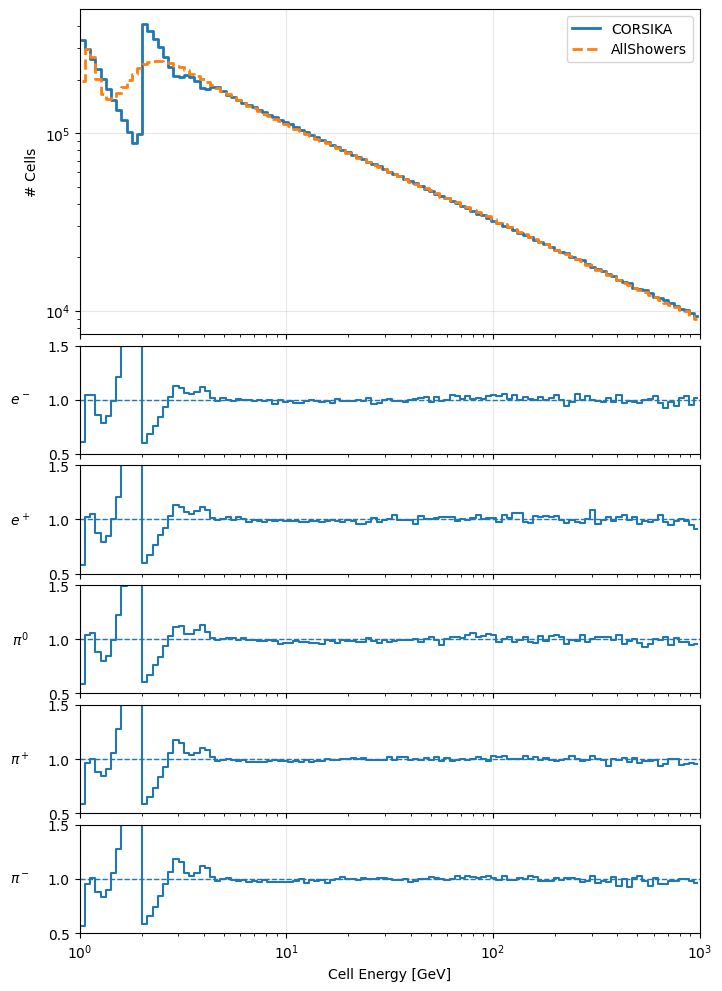

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

corsika_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"
allshowers_file = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"

PDG_NAMES = {
    11: r"$e^-$",
    -11: r"$e^+$",
    111: r"$\pi^0$",
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
}

PDG_ORDER = [11, -11, 111, 211, -211]


# ---------------------------------------------------------
# read cell energies grouped by PDG
def get_cell_energy_by_pdg(path, pdg_keep):
    energies_by_pdg = {pdg: [] for pdg in pdg_keep}
    all_energy = []

    with h5py.File(path, "r") as f:
        showers = f["showers"]
        pdg = f["pdg"][:]

        for s, p in zip(showers, pdg):
            arr = np.array(s).reshape(-1, 5)   # [x, y, z, e, t]
            e = arr[:, 3]                      # energy column
            all_energy.append(e)

            if p in energies_by_pdg:
                energies_by_pdg[p].append(e)

    all_energy = np.concatenate(all_energy) if len(all_energy) > 0 else np.array([])

    for p in energies_by_pdg:
        if len(energies_by_pdg[p]) > 0:
            energies_by_pdg[p] = np.concatenate(energies_by_pdg[p])
        else:
            energies_by_pdg[p] = np.array([])

    return all_energy, energies_by_pdg


# ---------------------------------------------------------
print("Loading CORSIKA...")
corsika_energy, corsika_by_pdg = get_cell_energy_by_pdg(corsika_file, PDG_ORDER)

print("Loading AllShowers...")
allshowers_energy, allshowers_by_pdg = get_cell_energy_by_pdg(allshowers_file, PDG_ORDER)


# ---------------------------------------------------------
# optional lower cut to match the real file better
emin = 1.0  # GeV

corsika_energy = corsika_energy[corsika_energy >= emin]
allshowers_energy = allshowers_energy[allshowers_energy >= emin]

for p in PDG_ORDER:
    corsika_by_pdg[p] = corsika_by_pdg[p][corsika_by_pdg[p] >= emin]
    allshowers_by_pdg[p] = allshowers_by_pdg[p][allshowers_by_pdg[p] >= emin]


# ---------------------------------------------------------
# common bins
bins = np.logspace(0, 3, 120)   # 1 GeV to 1000 GeV
centers = 0.5 * (bins[1:] + bins[:-1])

# total histograms
corsika_hist, _ = np.histogram(corsika_energy, bins=bins)
allshowers_hist, _ = np.histogram(allshowers_energy, bins=bins)


# ---------------------------------------------------------
# figure layout: 1 top panel + 5 ratio panels
fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(
    6, 1,
    height_ratios=[3, 1, 1, 1, 1, 1],
    hspace=0.08
)

ax_top = fig.add_subplot(gs[0])
ratio_axes = [fig.add_subplot(gs[i], sharex=ax_top) for i in range(1, 6)]


# ---------------------------------------------------------
# top total histogram
ax_top.step(centers, corsika_hist, where="mid", linewidth=2, label="CORSIKA")
ax_top.step(centers, allshowers_hist, where="mid", linestyle="--", linewidth=2, label="AllShowers")

ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_xlim(1, 1000)

ax_top.set_ylabel("# Cells")
ax_top.legend()
ax_top.grid(alpha=0.3)

plt.setp(ax_top.get_xticklabels(), visible=False)


# ---------------------------------------------------------
# ratio panels by PDG
for ax, p in zip(ratio_axes, PDG_ORDER):
    c_hist, _ = np.histogram(corsika_by_pdg[p], bins=bins)
    a_hist, _ = np.histogram(allshowers_by_pdg[p], bins=bins)

    ratio = np.full_like(c_hist, np.nan, dtype=float)
    mask = c_hist > 0
    ratio[mask] = a_hist[mask] / c_hist[mask]

    ax.step(centers, ratio, where="mid", linewidth=1.5)
    ax.axhline(1.0, linestyle="--", linewidth=1)

    ax.set_xscale("log")
    ax.set_xlim(1, 1000)
    ax.set_ylim(0.5, 1.5)
    ax.grid(alpha=0.3)

    ax.set_ylabel(PDG_NAMES[p], rotation=0, labelpad=20, va="center")

# only bottom ratio plot gets x label
for ax in ratio_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

ratio_axes[-1].set_xlabel("Cell Energy [GeV]")


plt.tight_layout()
plt.show()

Loading CORSIKA...
Loading AllShowers...


/tmp/ipykernel_3505708/1299991671.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


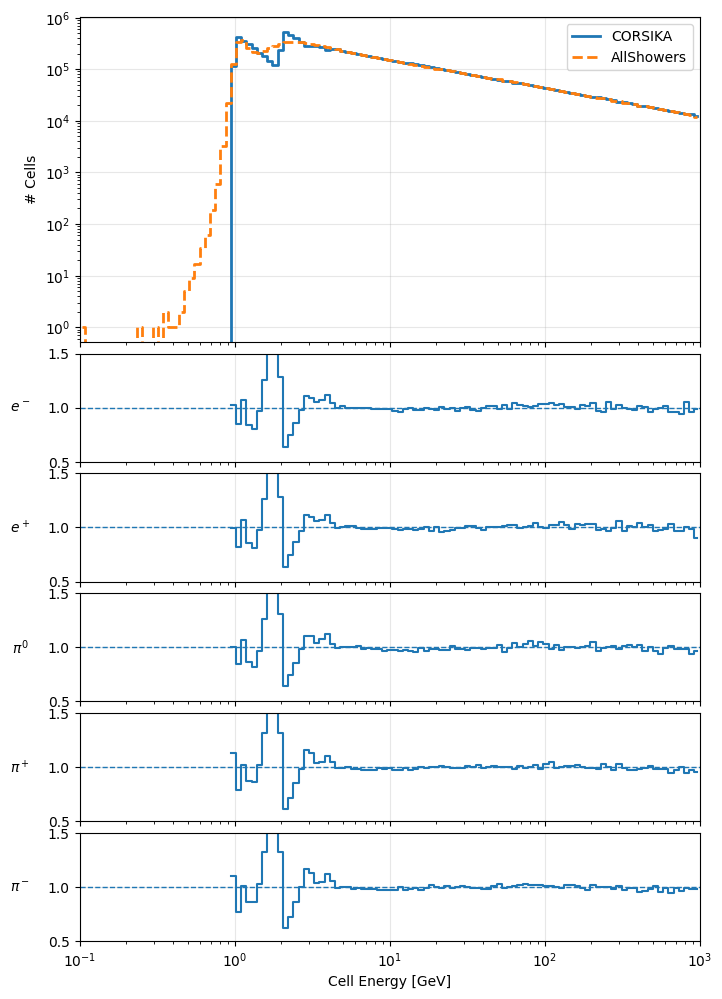

In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

corsika_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"
allshowers_file = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"

PDG_NAMES = {
    11: r"$e^-$",
    -11: r"$e^+$",
    111: r"$\pi^0$",
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
}

PDG_ORDER = [11, -11, 111, 211, -211]


# ---------------------------------------------------------
# read cell energies grouped by PDG
def get_cell_energy_by_pdg(path, pdg_keep):
    energies_by_pdg = {pdg: [] for pdg in pdg_keep}
    all_energy = []

    with h5py.File(path, "r") as f:
        showers = f["showers"]
        pdg = f["pdg"][:]

        for s, p in zip(showers, pdg):
            arr = np.array(s).reshape(-1, 5)   # [x, y, z, e, t]
            e = arr[:, 3]                      # energy column
            all_energy.append(e)

            if p in energies_by_pdg:
                energies_by_pdg[p].append(e)

    all_energy = np.concatenate(all_energy) if len(all_energy) > 0 else np.array([])

    for p in energies_by_pdg:
        if len(energies_by_pdg[p]) > 0:
            energies_by_pdg[p] = np.concatenate(energies_by_pdg[p])
        else:
            energies_by_pdg[p] = np.array([])

    return all_energy, energies_by_pdg


# ---------------------------------------------------------
print("Loading CORSIKA...")
corsika_energy, corsika_by_pdg = get_cell_energy_by_pdg(corsika_file, PDG_ORDER)

print("Loading AllShowers...")
allshowers_energy, allshowers_by_pdg = get_cell_energy_by_pdg(allshowers_file, PDG_ORDER)


# ---------------------------------------------------------
# optional lower cut to match the real file better
emin = 0.1

corsika_energy = corsika_energy[corsika_energy >= emin]
allshowers_energy = allshowers_energy[allshowers_energy >= emin]

for p in PDG_ORDER:
    corsika_by_pdg[p] = corsika_by_pdg[p][corsika_by_pdg[p] >= emin]
    allshowers_by_pdg[p] = allshowers_by_pdg[p][allshowers_by_pdg[p] >= emin]


# ---------------------------------------------------------
# common bins
bins = np.logspace(-1, 3, 120)   # 1 GeV to 1000 GeV
centers = 0.5 * (bins[1:] + bins[:-1])

# total histograms
corsika_hist, _ = np.histogram(corsika_energy, bins=bins)
allshowers_hist, _ = np.histogram(allshowers_energy, bins=bins)


# ---------------------------------------------------------
# figure layout: 1 top panel + 5 ratio panels
fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(
    6, 1,
    height_ratios=[3, 1, 1, 1, 1, 1],
    hspace=0.08
)

ax_top = fig.add_subplot(gs[0])
ratio_axes = [fig.add_subplot(gs[i], sharex=ax_top) for i in range(1, 6)]


# ---------------------------------------------------------
# top total histogram
ax_top.step(centers, corsika_hist, where="mid", linewidth=2, label="CORSIKA")
ax_top.step(centers, allshowers_hist, where="mid", linestyle="--", linewidth=2, label="AllShowers")

ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_xlim(0.1, 1000)

ax_top.set_ylabel("# Cells")
ax_top.legend()
ax_top.grid(alpha=0.3)

plt.setp(ax_top.get_xticklabels(), visible=False)


# ---------------------------------------------------------
# ratio panels by PDG
for ax, p in zip(ratio_axes, PDG_ORDER):
    c_hist, _ = np.histogram(corsika_by_pdg[p], bins=bins)
    a_hist, _ = np.histogram(allshowers_by_pdg[p], bins=bins)

    ratio = np.full_like(c_hist, np.nan, dtype=float)
    mask = c_hist > 0
    ratio[mask] = a_hist[mask] / c_hist[mask]

    ax.step(centers, ratio, where="mid", linewidth=1.5)
    ax.axhline(1.0, linestyle="--", linewidth=1)

    ax.set_xscale("log")
    ax.set_xlim(0.1, 1000)
    ax.set_ylim(0.5, 1.5)
    ax.grid(alpha=0.3)

    ax.set_ylabel(PDG_NAMES[p], rotation=0, labelpad=20, va="center")

# only bottom ratio plot gets x label
for ax in ratio_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

ratio_axes[-1].set_xlabel("Cell Energy [GeV]")


plt.tight_layout()
plt.show()

Loading CORSIKA...
Loading AllShowers...


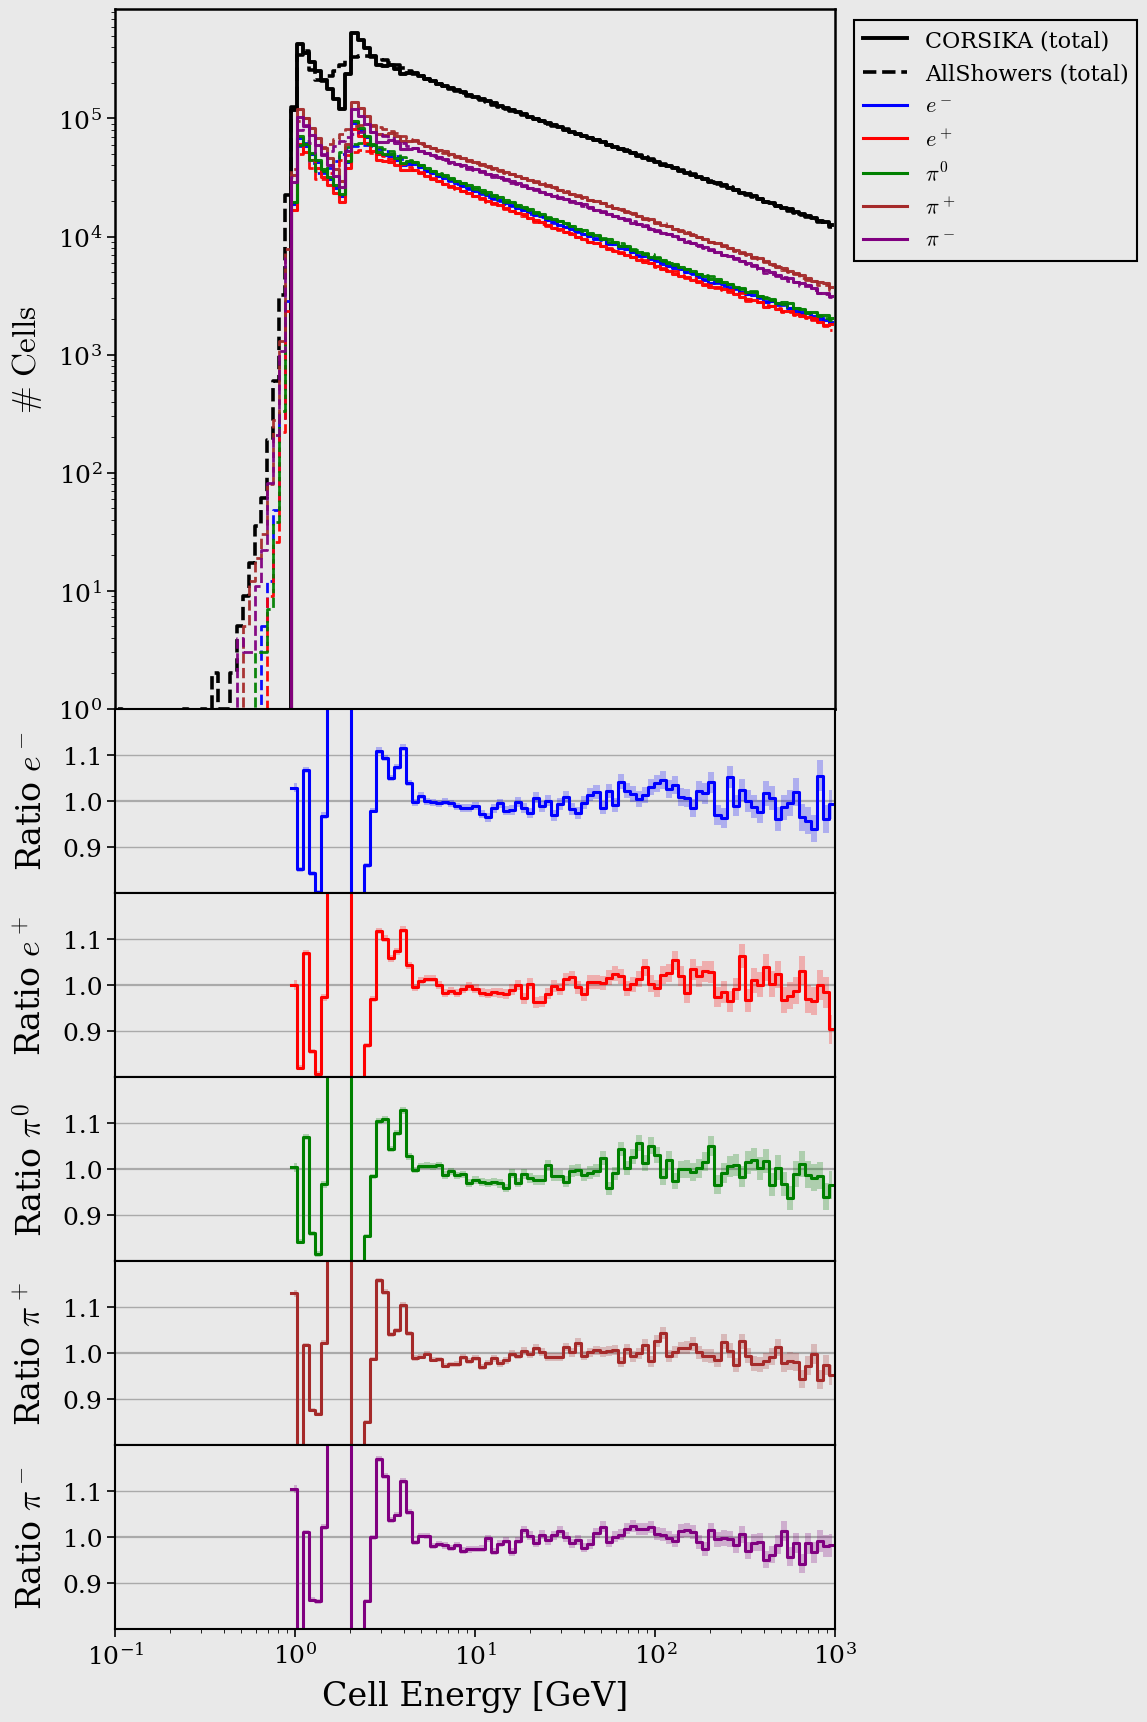

In [24]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# files
corsika_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"
allshowers_file = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"

PDG_NAMES = {
    11: r"$e^-$",
    -11: r"$e^+$",
    111: r"$\pi^0$",
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
}
PDG_ORDER = [11, -11, 111, 211, -211]

PDG_COLORS = {
    11: "blue",
    -11: "red",
    111: "green",
    211: "brown",
    -211: "purple",
}

# ---------------------------------------------------------
# global style
plt.rcParams.update({
    "figure.figsize": (20, 18),
    "figure.facecolor": "#e9e9e9",
    "axes.facecolor": "#e9e9e9",
    "savefig.facecolor": "#e9e9e9",
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.labelsize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# ---------------------------------------------------------
# read cell energies grouped by PDG
def get_cell_energy_by_pdg(path, pdg_keep):
    energies_by_pdg = {pdg: [] for pdg in pdg_keep}
    all_energy = []

    with h5py.File(path, "r") as f:
        showers = f["showers"]
        pdg = f["pdg"][:]

        for s, p in zip(showers, pdg):
            arr = np.array(s).reshape(-1, 5)   # [x, y, z, e, t]
            e = arr[:, 3]
            all_energy.append(e)

            if p in energies_by_pdg:
                energies_by_pdg[p].append(e)

    all_energy = np.concatenate(all_energy) if len(all_energy) > 0 else np.array([])

    for p in energies_by_pdg:
        if len(energies_by_pdg[p]) > 0:
            energies_by_pdg[p] = np.concatenate(energies_by_pdg[p])
        else:
            energies_by_pdg[p] = np.array([])

    return all_energy, energies_by_pdg

# ---------------------------------------------------------
print("Loading CORSIKA...")
corsika_energy, corsika_by_pdg = get_cell_energy_by_pdg(corsika_file, PDG_ORDER)

print("Loading AllShowers...")
allshowers_energy, allshowers_by_pdg = get_cell_energy_by_pdg(allshowers_file, PDG_ORDER)

# ---------------------------------------------------------
# lower energy cut
emin = 0.1

corsika_energy = corsika_energy[corsika_energy >= emin]
allshowers_energy = allshowers_energy[allshowers_energy >= emin]

for p in PDG_ORDER:
    corsika_by_pdg[p] = corsika_by_pdg[p][corsika_by_pdg[p] >= emin]
    allshowers_by_pdg[p] = allshowers_by_pdg[p][allshowers_by_pdg[p] >= emin]

# ---------------------------------------------------------
# common log-spaced bins
bins = np.logspace(-1, 3, 120)
centers = np.sqrt(bins[:-1] * bins[1:])   # geometric center for log bins

# total histograms
corsika_hist, _ = np.histogram(corsika_energy, bins=bins)
allshowers_hist, _ = np.histogram(allshowers_energy, bins=bins)

# ---------------------------------------------------------
# figure layout: 1 main panel + 5 ratio panels
fig = plt.figure()
gs = gridspec.GridSpec(
    6, 1,
    height_ratios=[3.8, 1, 1, 1, 1, 1],
    hspace=0.0
)

ax_top = fig.add_subplot(gs[0])
ratio_axes = [fig.add_subplot(gs[i], sharex=ax_top) for i in range(1, 6)]

# ---------------------------------------------------------
# top panel: total + per-PDG overlays
ax_top.step(
    centers, corsika_hist, where="mid",
    color="black", linewidth=2.8, label="CORSIKA (total)"
)
ax_top.step(
    centers, allshowers_hist, where="mid",
    color="black", linestyle="--", linewidth=2.6, label="AllShowers (total)"
)

for p in PDG_ORDER:
    c_hist, _ = np.histogram(corsika_by_pdg[p], bins=bins)
    a_hist, _ = np.histogram(allshowers_by_pdg[p], bins=bins)

    ax_top.step(
        centers, c_hist, where="mid",
        color=PDG_COLORS[p], linewidth=2.2, alpha=0.95
    )
    ax_top.step(
        centers, a_hist, where="mid",
        color=PDG_COLORS[p], linestyle="--", linewidth=2.0, alpha=0.95
    )

ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_xlim(1e-1, 1e3)
ax_top.set_ylim(1, max(corsika_hist.max(), allshowers_hist.max()) * 1.6)

ax_top.set_ylabel(r"$\#\ \mathrm{Cells}$", labelpad=10)
ax_top.grid(False)
ax_top.tick_params(axis="x", which="both", labelbottom=False)

# ---------------------------------------------------------
# legend outside the top panel
legend_elements = [
    Line2D([0], [0], color="black", lw=2.8, label="CORSIKA (total)"),
    Line2D([0], [0], color="black", lw=2.6, linestyle="--", label="AllShowers (total)")
]
for p in PDG_ORDER:
    legend_elements.append(
        Line2D([0], [0], color=PDG_COLORS[p], lw=2.2, label=PDG_NAMES[p])
    )

leg = ax_top.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fancybox=False,
)
frame = leg.get_frame()
frame.set_edgecolor("black")
frame.set_linewidth(1.5)
frame.set_facecolor("#e9e9e9")
frame.set_alpha(1.0)

# ---------------------------------------------------------
# ratio panels — one per PDG, with Poisson error bars
for ax, p in zip(ratio_axes, PDG_ORDER):
    c_hist, _ = np.histogram(corsika_by_pdg[p], bins=bins)
    a_hist, _ = np.histogram(allshowers_by_pdg[p], bins=bins)

    # ratio AllShowers / CORSIKA
    ratio = np.full_like(c_hist, np.nan, dtype=float)
    mask = c_hist > 0
    ratio[mask] = a_hist[mask] / c_hist[mask]

    # Full propagated Poisson error on ratio r = A / C:
    #   delta_r = sqrt( A/C^2 + A^2/C^3 ) = (sqrt(A)/C) * sqrt(1 + A/C)
    # Assumes both A and C are Poisson-distributed.
    err = np.full_like(ratio, np.nan, dtype=float)
    err[mask] = (np.sqrt(a_hist[mask]) / c_hist[mask]) * np.sqrt(
        1.0 + a_hist[mask] / c_hist[mask]
    )

    color = PDG_COLORS[p]

    # horizontal guide lines
    for y in [0.9, 1.0, 1.1]:
        ax.axhline(y, color="gray", lw=1.0 if y != 1.0 else 1.6, alpha=0.6)

    # ratio step line
    ax.step(centers, ratio, where="mid", color=color, linewidth=2.2)

    # Poisson error as transparent fill band
    valid = mask & np.isfinite(err) & np.isfinite(ratio)
    ax.fill_between(
        centers[valid],
        (ratio - err)[valid],
        (ratio + err)[valid],
        step="mid",
        color=color,
        alpha=0.25,
        linewidth=0,
        zorder=2,
    )

    ax.set_xscale("log")
    ax.set_xlim(1e-1, 1e3)
    ax.set_ylim(0.8, 1.2)
    ax.set_yticks([0.9, 1.0, 1.1])

    ax.set_ylabel(
        rf"Ratio {PDG_NAMES[p]}",
        rotation=90,
        labelpad=22,
        va="center"
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# hide x tick labels on all but the bottom ratio panel
for ax in ratio_axes[:-1]:
    ax.tick_params(axis="x", which="both", labelbottom=False)

ratio_axes[-1].set_xlabel(r"Cell Energy [GeV]", labelpad=8)

plt.subplots_adjust(left=0.6, right=0.96, top=0.98, bottom=0.08)
plt.savefig("cell_energy_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

Loading CORSIKA...
Loading AllShowers...


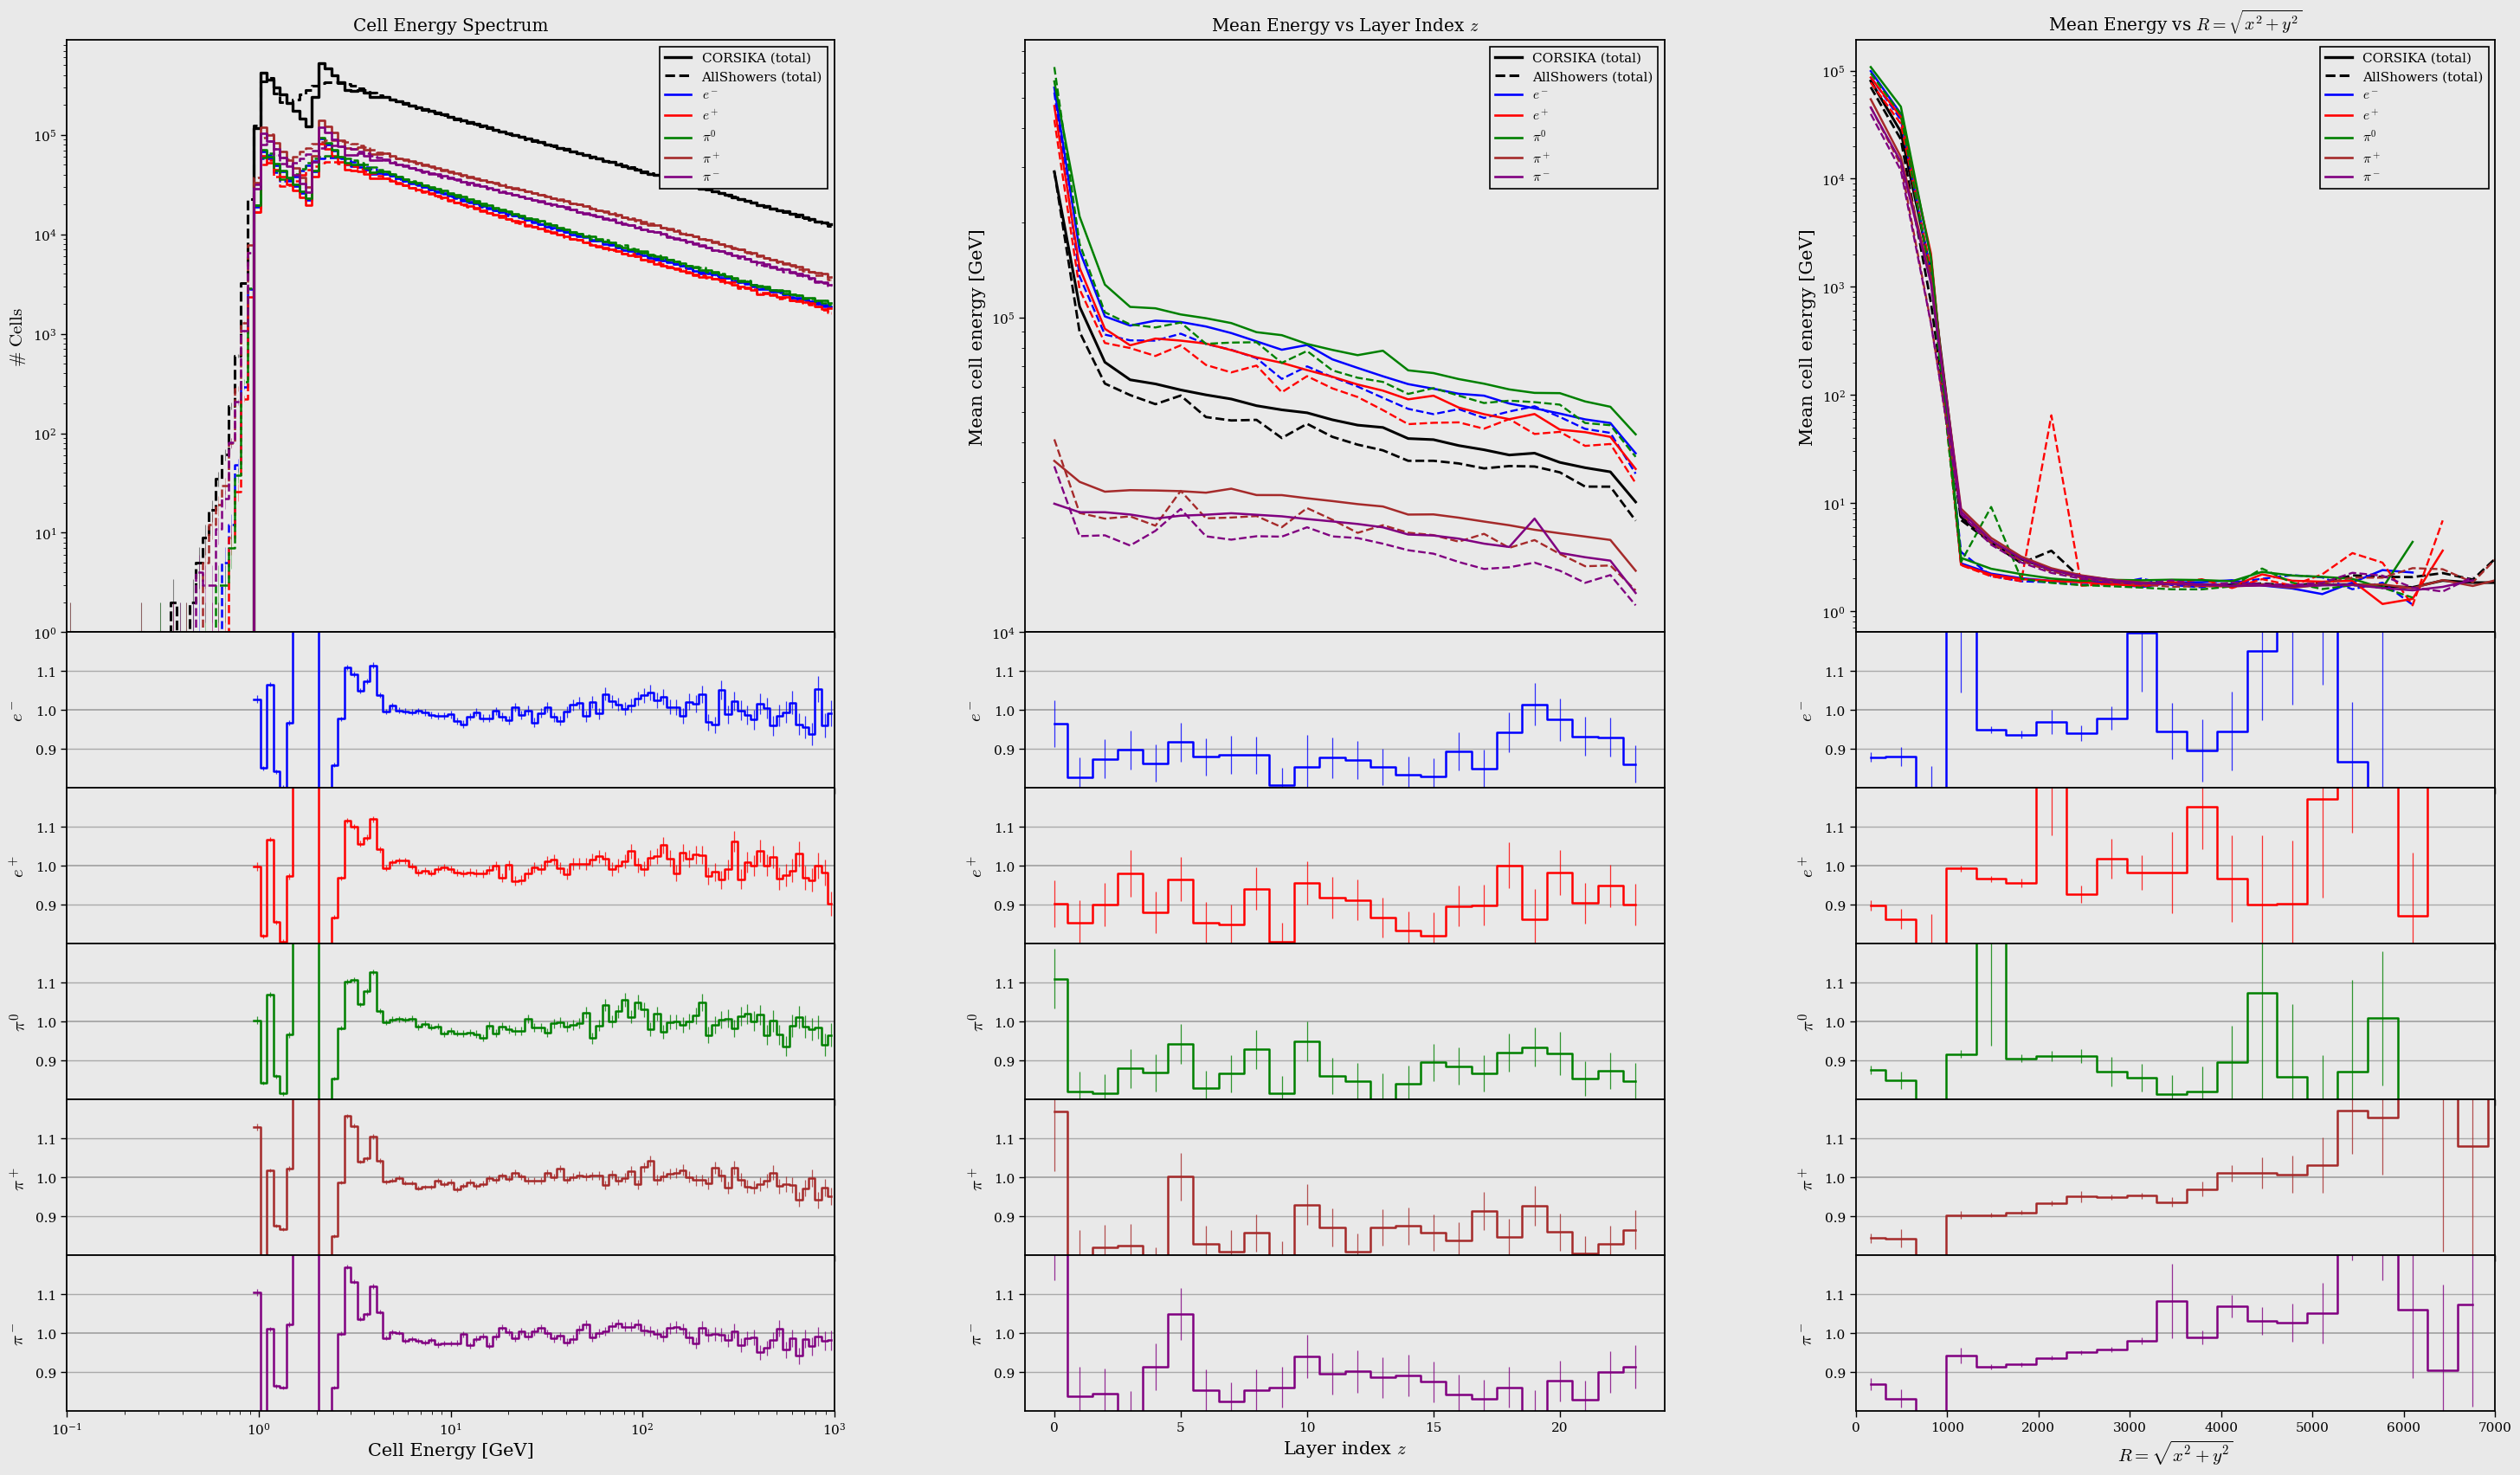

In [32]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# files
corsika_file = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_simulations/all_shower_processed_step1_with_bins_256_with_time/merged_all_showers_test.h5"
allshowers_file = "/n/home04/hhanif/AllShowers/results/20260307_092911_CNF-Transformer/samples00.h5"

PDG_NAMES = {
    11: r"$e^-$",
    -11: r"$e^+$",
    111: r"$\pi^0$",
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
}
PDG_ORDER = [11, -11, 111, 211, -211]

PDG_COLORS = {
    11: "blue",
    -11: "red",
    111: "green",
    211: "brown",
    -211: "purple",
}

# ---------------------------------------------------------
# global style
plt.rcParams.update({
    "figure.figsize": (30, 18),
    "figure.facecolor": "#e9e9e9",
    "axes.facecolor": "#e9e9e9",
    "savefig.facecolor": "#e9e9e9",
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# ---------------------------------------------------------
# load all hit info grouped by PDG
def load_hits_by_pdg(path, pdg_keep):
    data = {
        "total": {"x": [], "y": [], "z": [], "e": []},
        "pdg": {p: {"x": [], "y": [], "z": [], "e": []} for p in pdg_keep}
    }

    with h5py.File(path, "r") as f:
        showers = f["showers"]
        pdg_arr = f["pdg"][:]

        for s, p in zip(showers, pdg_arr):
            arr = np.array(s).reshape(-1, 5)   # [x, y, z, e, t]
            x = arr[:, 0]
            y = arr[:, 1]
            z = arr[:, 2]
            e = arr[:, 3]

            data["total"]["x"].append(x)
            data["total"]["y"].append(y)
            data["total"]["z"].append(z)
            data["total"]["e"].append(e)

            if p in pdg_keep:
                data["pdg"][p]["x"].append(x)
                data["pdg"][p]["y"].append(y)
                data["pdg"][p]["z"].append(z)
                data["pdg"][p]["e"].append(e)

    # concatenate
    for key in ["x", "y", "z", "e"]:
        if len(data["total"][key]) > 0:
            data["total"][key] = np.concatenate(data["total"][key])
        else:
            data["total"][key] = np.array([])

    for p in pdg_keep:
        for key in ["x", "y", "z", "e"]:
            if len(data["pdg"][p][key]) > 0:
                data["pdg"][p][key] = np.concatenate(data["pdg"][p][key])
            else:
                data["pdg"][p][key] = np.array([])

    return data

# ---------------------------------------------------------
# apply lower energy cut
def apply_energy_cut(data, emin):
    out = {
        "total": {},
        "pdg": {}
    }

    e = data["total"]["e"]
    mask = e >= emin
    for key in ["x", "y", "z", "e"]:
        out["total"][key] = data["total"][key][mask]

    for p in data["pdg"]:
        out["pdg"][p] = {}
        e = data["pdg"][p]["e"]
        mask = e >= emin
        for key in ["x", "y", "z", "e"]:
            out["pdg"][p][key] = data["pdg"][p][key][mask]

    return out

# ---------------------------------------------------------
# mean profile vs integer z with SEM error
def profile_vs_z(z, e):
    z_int = z.astype(int)
    z_vals = np.sort(np.unique(z_int))

    x = []
    mean = []
    sem = []

    for zz in z_vals:
        vals = e[z_int == zz]
        if len(vals) > 0:
            x.append(zz)
            mean.append(np.mean(vals))
            if len(vals) > 1:
                sem.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))
            else:
                sem.append(0.0)

    return np.array(x), np.array(mean), np.array(sem)

# ---------------------------------------------------------
# mean profile vs R with SEM error
def profile_vs_r(x, y, e, r_bins):
    r = np.sqrt(x**2 + y**2)
    inds = np.digitize(r, r_bins) - 1
    centers = 0.5 * (r_bins[:-1] + r_bins[1:])

    xc = []
    mean = []
    sem = []

    for i in range(len(centers)):
        vals = e[inds == i]
        if len(vals) > 0:
            xc.append(centers[i])
            mean.append(np.mean(vals))
            if len(vals) > 1:
                sem.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))
            else:
                sem.append(0.0)

    return np.array(xc), np.array(mean), np.array(sem)

# ---------------------------------------------------------
# general ratio A/C with propagated uncertainties
def ratio_with_error(a, aerr, c, cerr):
    ratio = np.full(len(a), np.nan, dtype=float)
    err = np.full(len(a), np.nan, dtype=float)

    mask = (c > 0) & np.isfinite(a) & np.isfinite(c)
    ratio[mask] = a[mask] / c[mask]

    mask2 = mask & (a > 0)
    err[mask2] = ratio[mask2] * np.sqrt(
        (aerr[mask2] / a[mask2])**2 + (cerr[mask2] / c[mask2])**2
    )

    zero_num = mask & (a == 0)
    ratio[zero_num] = 0.0

    return ratio, err

# ---------------------------------------------------------
# common x alignment for z profiles
def align_profiles(x1, y1, e1, x2, y2, e2):
    common = np.intersect1d(x1, x2)
    i1 = np.searchsorted(x1, common)
    i2 = np.searchsorted(x2, common)
    return common, y1[i1], e1[i1], y2[i2], e2[i2]

# ---------------------------------------------------------
# plotting helper for ratio panels
def draw_ratio_panel(ax, x, ratio, err, color, ylabel, xscale=None):
    for yref in [0.9, 1.0, 1.1]:
        ax.axhline(yref, color="gray", lw=1.0 if yref != 1.0 else 1.4, alpha=0.6)

    if xscale == "log":
        ax.step(x, ratio, where="mid", color=color, linewidth=1.8)
    else:
        ax.step(x, ratio, where="mid", color=color, linewidth=1.8)

    valid = np.isfinite(ratio) & np.isfinite(err)
    ax.errorbar(
        x[valid], ratio[valid], yerr=err[valid],
        fmt="none", ecolor=color, elinewidth=0.9, capsize=0, alpha=0.8
    )

    if xscale == "log":
        ax.set_xscale("log")

    ax.set_ylim(0.8, 1.2)
    ax.set_yticks([0.9, 1.0, 1.1])
    ax.set_ylabel(ylabel, rotation=90, labelpad=14, va="center")
    ax.grid(False)

# ---------------------------------------------------------
print("Loading CORSIKA...")
corsika = load_hits_by_pdg(corsika_file, PDG_ORDER)

print("Loading AllShowers...")
allshowers = load_hits_by_pdg(allshowers_file, PDG_ORDER)

# ---------------------------------------------------------
# lower energy cut
emin = 0.1
corsika = apply_energy_cut(corsika, emin)
allshowers = apply_energy_cut(allshowers, emin)

# ---------------------------------------------------------
# spectrum bins
spec_bins = np.logspace(-1, 3, 120)
spec_centers = np.sqrt(spec_bins[:-1] * spec_bins[1:])

# ---------------------------------------------------------
# common R bins from totals
r_c_total = np.sqrt(corsika["total"]["x"]**2 + corsika["total"]["y"]**2)
r_a_total = np.sqrt(allshowers["total"]["x"]**2 + allshowers["total"]["y"]**2)
r_max = max(r_c_total.max(), r_a_total.max())
r_bins = np.linspace(0.0, r_max, 61)

# ---------------------------------------------------------
# build total profiles
z_tot_c_x, z_tot_c_mean, z_tot_c_sem = profile_vs_z(corsika["total"]["z"], corsika["total"]["e"])
z_tot_a_x, z_tot_a_mean, z_tot_a_sem = profile_vs_z(allshowers["total"]["z"], allshowers["total"]["e"])

r_tot_c_x, r_tot_c_mean, r_tot_c_sem = profile_vs_r(
    corsika["total"]["x"], corsika["total"]["y"], corsika["total"]["e"], r_bins
)
r_tot_a_x, r_tot_a_mean, r_tot_a_sem = profile_vs_r(
    allshowers["total"]["x"], allshowers["total"]["y"], allshowers["total"]["e"], r_bins
)

# ---------------------------------------------------------
# build PDG profiles
z_prof_c = {}
z_prof_a = {}
r_prof_c = {}
r_prof_a = {}

for p in PDG_ORDER:
    z_prof_c[p] = profile_vs_z(corsika["pdg"][p]["z"], corsika["pdg"][p]["e"])
    z_prof_a[p] = profile_vs_z(allshowers["pdg"][p]["z"], allshowers["pdg"][p]["e"])

    r_prof_c[p] = profile_vs_r(
        corsika["pdg"][p]["x"], corsika["pdg"][p]["y"], corsika["pdg"][p]["e"], r_bins
    )
    r_prof_a[p] = profile_vs_r(
        allshowers["pdg"][p]["x"], allshowers["pdg"][p]["y"], allshowers["pdg"][p]["e"], r_bins
    )

# ---------------------------------------------------------
# figure layout:
# 3 columns, each column has top + 5 PDG ratio panels
fig = plt.figure()
outer = gridspec.GridSpec(1, 3, width_ratios=[1.2, 1.0, 1.0], wspace=0.28)

col1 = gridspec.GridSpecFromSubplotSpec(
    6, 1, subplot_spec=outer[0],
    height_ratios=[3.8, 1, 1, 1, 1, 1], hspace=0.0
)
col2 = gridspec.GridSpecFromSubplotSpec(
    6, 1, subplot_spec=outer[1],
    height_ratios=[3.8, 1, 1, 1, 1, 1], hspace=0.0
)
col3 = gridspec.GridSpecFromSubplotSpec(
    6, 1, subplot_spec=outer[2],
    height_ratios=[3.8, 1, 1, 1, 1, 1], hspace=0.0
)

ax1_top = fig.add_subplot(col1[0])
ax1_ratios = [fig.add_subplot(col1[i], sharex=ax1_top) for i in range(1, 6)]

ax2_top = fig.add_subplot(col2[0])
ax2_ratios = [fig.add_subplot(col2[i], sharex=ax2_top) for i in range(1, 6)]

ax3_top = fig.add_subplot(col3[0])
ax3_ratios = [fig.add_subplot(col3[i], sharex=ax3_top) for i in range(1, 6)]

# =========================================================
# COLUMN 1: CELL ENERGY SPECTRUM
# =========================================================
c_tot_hist, _ = np.histogram(corsika["total"]["e"], bins=spec_bins)
a_tot_hist, _ = np.histogram(allshowers["total"]["e"], bins=spec_bins)

ax1_top.step(spec_centers, c_tot_hist, where="mid", color="black", linewidth=2.4, label="CORSIKA (total)")
ax1_top.errorbar(
    spec_centers, c_tot_hist, yerr=np.sqrt(c_tot_hist),
    fmt="none", ecolor="black", elinewidth=0.8, capsize=0, alpha=0.7
)

ax1_top.step(spec_centers, a_tot_hist, where="mid", color="black", linestyle="--", linewidth=2.2, label="AllShowers (total)")
ax1_top.errorbar(
    spec_centers, a_tot_hist, yerr=np.sqrt(a_tot_hist),
    fmt="none", ecolor="black", elinewidth=0.8, capsize=0, alpha=0.45
)

for p in PDG_ORDER:
    c_hist, _ = np.histogram(corsika["pdg"][p]["e"], bins=spec_bins)
    a_hist, _ = np.histogram(allshowers["pdg"][p]["e"], bins=spec_bins)

    ax1_top.step(spec_centers, c_hist, where="mid", color=PDG_COLORS[p], linewidth=1.9)
    ax1_top.errorbar(
        spec_centers, c_hist, yerr=np.sqrt(c_hist),
        fmt="none", ecolor=PDG_COLORS[p], elinewidth=0.7, capsize=0, alpha=0.55
    )

    ax1_top.step(spec_centers, a_hist, where="mid", color=PDG_COLORS[p], linestyle="--", linewidth=1.8)
    ax1_top.errorbar(
        spec_centers, a_hist, yerr=np.sqrt(a_hist),
        fmt="none", ecolor=PDG_COLORS[p], elinewidth=0.7, capsize=0, alpha=0.35
    )

ax1_top.set_xscale("log")
ax1_top.set_yscale("log")
ax1_top.set_xlim(1e-1, 1e3)
ax1_top.set_ylim(1, max(c_tot_hist.max(), a_tot_hist.max()) * 1.7)
ax1_top.set_ylabel(r"$\#\ \mathrm{Cells}$")
ax1_top.set_title("Cell Energy Spectrum", pad=8)
ax1_top.tick_params(axis="x", which="both", labelbottom=False)

legend_elements = [
    Line2D([0], [0], color="black", lw=2.4, label="CORSIKA (total)"),
    Line2D([0], [0], color="black", lw=2.2, linestyle="--", label="AllShowers (total)")
]
for p in PDG_ORDER:
    legend_elements.append(Line2D([0], [0], color=PDG_COLORS[p], lw=1.9, label=PDG_NAMES[p]))

leg = ax1_top.legend(handles=legend_elements, loc="upper right", frameon=True, fancybox=False)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.2)
leg.get_frame().set_facecolor("#e9e9e9")
leg.get_frame().set_alpha(1.0)

for ax, p in zip(ax1_ratios, PDG_ORDER):
    c_hist, _ = np.histogram(corsika["pdg"][p]["e"], bins=spec_bins)
    a_hist, _ = np.histogram(allshowers["pdg"][p]["e"], bins=spec_bins)

    ratio = np.full_like(c_hist, np.nan, dtype=float)
    err = np.full_like(c_hist, np.nan, dtype=float)
    mask = c_hist > 0
    ratio[mask] = a_hist[mask] / c_hist[mask]

    err[mask] = (np.sqrt(a_hist[mask]) / c_hist[mask]) * np.sqrt(
        1.0 + a_hist[mask] / c_hist[mask]
    )

    draw_ratio_panel(ax, spec_centers, ratio, err, PDG_COLORS[p], PDG_NAMES[p], xscale="log")
    ax.set_xlim(1e-1, 1e3)

for ax in ax1_ratios[:-1]:
    ax.tick_params(axis="x", which="both", labelbottom=False)
ax1_ratios[-1].set_xlabel(r"Cell Energy [GeV]")

# =========================================================
# COLUMN 2: MEAN ENERGY VS LAYER INDEX z
# =========================================================
# total curves
zx, cmean, csem, amean, asem = align_profiles(
    z_tot_c_x, z_tot_c_mean, z_tot_c_sem,
    z_tot_a_x, z_tot_a_mean, z_tot_a_sem
)

ax2_top.plot(zx, cmean, "-", color="black", linewidth=2.2)

ax2_top.plot(zx, amean, "--", color="black", linewidth=2.0)

for p in PDG_ORDER:
    zc_x, zc_mean, zc_sem = z_prof_c[p]
    za_x, za_mean, za_sem = z_prof_a[p]

    zz, c_m, c_s, a_m, a_s = align_profiles(zc_x, zc_mean, zc_sem, za_x, za_mean, za_sem)

    ax2_top.plot(zz, c_m, "-", color=PDG_COLORS[p], linewidth=1.8)
    ax2_top.plot(zz, a_m, "--", color=PDG_COLORS[p], linewidth=1.7)
ax2_top.set_yscale("log")

ax2_top.set_ylabel(r"Mean cell energy [GeV]")
ax2_top.set_title(r"Mean Energy vs Layer Index $z$", pad=8)
ax2_top.tick_params(axis="x", which="both", labelbottom=False)

leg2 = ax2_top.legend(handles=legend_elements, loc="upper right", frameon=True, fancybox=False)
leg2.get_frame().set_edgecolor("black")
leg2.get_frame().set_linewidth(1.2)
leg2.get_frame().set_facecolor("#e9e9e9")
leg2.get_frame().set_alpha(1.0)

for ax, p in zip(ax2_ratios, PDG_ORDER):
    zc_x, zc_mean, zc_sem = z_prof_c[p]
    za_x, za_mean, za_sem = z_prof_a[p]

    zz, c_m, c_s, a_m, a_s = align_profiles(zc_x, zc_mean, zc_sem, za_x, za_mean, za_sem)
    ratio, err = ratio_with_error(a_m, a_s, c_m, c_s)

    draw_ratio_panel(ax, zz, ratio, err, PDG_COLORS[p], PDG_NAMES[p], xscale=None)

for ax in ax2_ratios[:-1]:
    ax.tick_params(axis="x", which="both", labelbottom=False)
ax2_ratios[-1].set_xlabel(r"Layer index $z$")

# =========================================================
# COLUMN 3: MEAN ENERGY VS R
# =========================================================
# total curves
ratio_r_tot, err_r_tot = None, None  # unused, just placeholder

# for total, bins already match by construction
ax3_top.plot(r_tot_c_x, r_tot_c_mean, "-", color="black", linewidth=2.2)
ax3_top.plot(r_tot_a_x, r_tot_a_mean, "--", color="black", linewidth=2.0)

for p in PDG_ORDER:
    rc_x, rc_mean, rc_sem = r_prof_c[p]
    ra_x, ra_mean, ra_sem = r_prof_a[p]

    # same R bins, but some empty bins may differ; align by x
    rr, c_m, c_s, a_m, a_s = align_profiles(rc_x, rc_mean, rc_sem, ra_x, ra_mean, ra_sem)

    ax3_top.plot(rr, c_m, "-", color=PDG_COLORS[p], linewidth=1.8)
    ax3_top.plot(rr, a_m, "--", color=PDG_COLORS[p], linewidth=1.7)
ax3_top.set_yscale("log")
ax3_top.set_ylabel(r"Mean cell energy [GeV]")
ax3_top.set_title(r"Mean Energy vs $R=\sqrt{x^2+y^2}$", pad=8)
ax3_top.tick_params(axis="x", which="both", labelbottom=False)
ax3_top.set_xlim(0, 7000)
leg3 = ax3_top.legend(handles=legend_elements, loc="upper right", frameon=True, fancybox=False)
leg3.get_frame().set_edgecolor("black")
leg3.get_frame().set_linewidth(1.2)
leg3.get_frame().set_facecolor("#e9e9e9")
leg3.get_frame().set_alpha(1.0)

for ax, p in zip(ax3_ratios, PDG_ORDER):
    rc_x, rc_mean, rc_sem = r_prof_c[p]
    ra_x, ra_mean, ra_sem = r_prof_a[p]

    rr, c_m, c_s, a_m, a_s = align_profiles(rc_x, rc_mean, rc_sem, ra_x, ra_mean, ra_sem)
    ratio, err = ratio_with_error(a_m, a_s, c_m, c_s)

    draw_ratio_panel(ax, rr, ratio, err, PDG_COLORS[p], PDG_NAMES[p], xscale=None)

for ax in ax3_ratios[:-1]:
    ax.tick_params(axis="x", which="both", labelbottom=False)
ax3_ratios[-1].set_xlabel(r"$R=\sqrt{x^2+y^2}$")

# ---------------------------------------------------------
# style spines
all_axes = [ax1_top, *ax1_ratios, ax2_top, *ax2_ratios, ax3_top, *ax3_ratios]
for ax in all_axes:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)

plt.subplots_adjust(left=0.05, right=0.985, top=0.95, bottom=0.07)
plt.savefig("cell_energy_three_columns_all_with_5_pdg_ratios.png", dpi=150, bbox_inches="tight")
plt.show()